# 03 - Feature Analysis Notebook

Notebook này là khung tự học cho **Leakage Audit và Feature Engineering Design** của project Credit Risk Scoring & Loan Decisioning System.

Nguyên tắc sử dụng:
- Không train model chính thức trong notebook này.
- Không xử lý dữ liệu trực tiếp trên `df_raw`; chỉ thiết kế feature set và kiểm tra logic.
- Mọi feature mới phải có ý nghĩa nghiệp vụ, không tạo hàng loạt feature vô thức.
- Tách rõ **Primary Feature Set** và **Extended Feature Set**.
- Ghi rõ lý do loại hoặc giữ các biến có rủi ro leakage/sensitive/proxy.

## Section 0 - Mục tiêu và phạm vi Feature Analysis

**Mục tiêu:** chuẩn bị dữ liệu và feature set đủ rõ ràng trước modeling.

**Input:** dataset raw, kết quả Data Audit, kết quả EDA.

**Output mong muốn:**
- Leakage review table.
- Primary/Extended feature set.
- Preprocessing design cho numeric/categorical/missing/outlier.
- Feature engineering candidates có lý do nghiệp vụ.
- Feature validation checklist.
- Draft hướng chuyển logic sang `src/data/preprocessing.py` và `src/features/build_features.py`.

In [1]:
# 0.1 - Thiết lập môi trường notebook

import random
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display

# ============================================================
# 1. Cấu hình hiển thị
# ============================================================

pd.set_option("display.max_columns", 120)
pd.set_option("display.max_rows", 120)
pd.set_option("display.width", 1200)
pd.set_option("display.float_format", lambda value: f"{value:,.4f}")
sns.set_theme(style="whitegrid")

# ============================================================
# 2. Hằng số chính của project
# ============================================================

TARGET_COL = "loan_status"
ID_COL = "client_ID"
DATA_SHEET_NAME = "Credit Risk Data"
DICTIONARY_SHEET_NAME = "Data Dictionary"

RANDOM_STATE = 42
random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

# ============================================================
# 3. Watchlist dùng cho Leakage Audit / Feature Set Design
# ============================================================

POTENTIAL_LEAKAGE_COLS = [
    "loan_grade",
    "loan_int_rate",
]

SENSITIVE_OR_PROXY_COLS = [
    "gender",
    "country",
    "state",
    "city",
    "city_latitude",
    "city_longitude",
]

print("Environment ready for Feature Analysis")
print(f"TARGET_COL            : {TARGET_COL}")
print(f"ID_COL                : {ID_COL}")
print(f"DATA_SHEET_NAME       : {DATA_SHEET_NAME}")
print(f"DICTIONARY_SHEET_NAME : {DICTIONARY_SHEET_NAME}")
print(f"RANDOM_STATE          : {RANDOM_STATE}")
print(f"POTENTIAL_LEAKAGE_COLS: {POTENTIAL_LEAKAGE_COLS}")
print(f"SENSITIVE_OR_PROXY_COLS: {SENSITIVE_OR_PROXY_COLS}")

Environment ready for Feature Analysis
TARGET_COL            : loan_status
ID_COL                : client_ID
DATA_SHEET_NAME       : Credit Risk Data
DICTIONARY_SHEET_NAME : Data Dictionary
RANDOM_STATE          : 42
POTENTIAL_LEAKAGE_COLS: ['loan_grade', 'loan_int_rate']
SENSITIVE_OR_PROXY_COLS: ['gender', 'country', 'state', 'city', 'city_latitude', 'city_longitude']


In [2]:
# 0.2 - Xác định path và load dữ liệu

# ============================================================
# 1. Xác định PROJECT_ROOT
# ============================================================

CURRENT_CWD = Path.cwd().resolve()


def find_project_root(start: Path) -> Path:
    """Tìm thư mục gốc project từ CWD hiện tại hoặc các thư mục cha."""
    for candidate in (start, *start.parents):
        required_folders = ("data", "notebooks", "src")
        if all((candidate / folder).exists() for folder in required_folders):
            return candidate

    raise FileNotFoundError(
        "Không xác định được PROJECT_ROOT. "
        "Hãy chạy notebook từ trong repo CREDIT_RISK_PROJECT hoặc một thư mục con của repo."
    )


PROJECT_ROOT = find_project_root(CURRENT_CWD)

# ============================================================
# 2. Khai báo đường dẫn chính
# ============================================================

RAW_DATA_DIR = PROJECT_ROOT / "data" / "raw"
RAW_DATA_PATH = RAW_DATA_DIR / "Credit Risk Dataset.xlsx"
REPORT_PATH = PROJECT_ROOT / "reports"
FIGURE_PATH = PROJECT_ROOT / "notebooks" / "figures"

REPORT_PATH.mkdir(parents=True, exist_ok=True)
FIGURE_PATH.mkdir(parents=True, exist_ok=True)

print(f"CWD           : {CURRENT_CWD}")
print(f"PROJECT_ROOT  : {PROJECT_ROOT}")
print(f"RAW_DATA_PATH : {RAW_DATA_PATH}")
print(f"File tồn tại  : {RAW_DATA_PATH.exists()}")
print(f"REPORT_PATH   : {REPORT_PATH}")
print(f"FIGURE_PATH   : {FIGURE_PATH}")

if not RAW_DATA_PATH.exists():
    raise FileNotFoundError(
        f"Không tìm thấy dataset tại: {RAW_DATA_PATH}. "
        "Hãy kiểm tra file 'Credit Risk Dataset.xlsx' trong data/raw/."
    )

# ============================================================
# 3. Load dữ liệu raw
# ============================================================

file_suffix = RAW_DATA_PATH.suffix.lower()

if file_suffix in {".xlsx", ".xls"}:
    excel_file = pd.ExcelFile(RAW_DATA_PATH, engine="openpyxl")
    print(f"\nCác sheet trong workbook: {excel_file.sheet_names}")

    if DATA_SHEET_NAME not in excel_file.sheet_names:
        raise ValueError(
            f"Không tìm thấy sheet '{DATA_SHEET_NAME}'. "
            f"Các sheet hiện có: {excel_file.sheet_names}"
        )

    df_raw = pd.read_excel(
        RAW_DATA_PATH,
        sheet_name=DATA_SHEET_NAME,
        engine="openpyxl",
    )

    if DICTIONARY_SHEET_NAME in excel_file.sheet_names:
        data_dictionary_raw = pd.read_excel(
            RAW_DATA_PATH,
            sheet_name=DICTIONARY_SHEET_NAME,
            engine="openpyxl",
        )
    else:
        data_dictionary_raw = pd.DataFrame()

elif file_suffix == ".csv":
    df_raw = pd.read_csv(RAW_DATA_PATH)
    data_dictionary_raw = pd.DataFrame()

else:
    raise ValueError(f"Định dạng file chưa được hỗ trợ: {file_suffix}")

df_feature = df_raw.copy()
RAW_SHAPE = df_raw.shape

# ============================================================
# 4. Kiểm tra shape, target, ID và schema cơ bản
# ============================================================

required_cols = [
    TARGET_COL,
    ID_COL,
]

missing_required_cols = [
    col for col in required_cols
    if col not in df_raw.columns
]

if missing_required_cols:
    raise KeyError(
        "Dataset thiếu các cột bắt buộc: "
        + ", ".join(missing_required_cols)
    )

duplicate_column_count = int(df_raw.columns.duplicated().sum())
target_missing_count = int(df_raw[TARGET_COL].isna().sum())
id_missing_count = int(df_raw[ID_COL].isna().sum())
id_unique_count = int(df_raw[ID_COL].nunique(dropna=True))
id_duplicate_count = int(df_raw[ID_COL].duplicated().sum())
target_values = sorted(df_raw[TARGET_COL].dropna().unique().tolist())

available_potential_leakage_cols = [
    col for col in POTENTIAL_LEAKAGE_COLS
    if col in df_raw.columns
]

available_sensitive_or_proxy_cols = [
    col for col in SENSITIVE_OR_PROXY_COLS
    if col in df_raw.columns
]

feature_candidate_cols = [
    col for col in df_raw.columns
    if col not in {TARGET_COL, ID_COL}
]

numeric_candidate_cols = (
    df_raw[feature_candidate_cols]
    .select_dtypes(include=[np.number])
    .columns
    .tolist()
)

categorical_candidate_cols = [
    col for col in feature_candidate_cols
    if col not in numeric_candidate_cols
]

load_health_summary = pd.DataFrame([
    {
        "metric": "rows",
        "value": RAW_SHAPE[0],
    },
    {
        "metric": "columns",
        "value": RAW_SHAPE[1],
    },
    {
        "metric": "duplicate_columns",
        "value": duplicate_column_count,
    },
    {
        "metric": "target_missing_count",
        "value": target_missing_count,
    },
    {
        "metric": "id_missing_count",
        "value": id_missing_count,
    },
    {
        "metric": "id_unique_count",
        "value": id_unique_count,
    },
    {
        "metric": "id_duplicate_count",
        "value": id_duplicate_count,
    },
    {
        "metric": "feature_candidate_count",
        "value": len(feature_candidate_cols),
    },
    {
        "metric": "numeric_candidate_count",
        "value": len(numeric_candidate_cols),
    },
    {
        "metric": "categorical_candidate_count",
        "value": len(categorical_candidate_cols),
    },
])

missing_overview = (
    df_raw
    .isna()
    .sum()
    .rename("missing_count")
    .to_frame()
)

missing_overview["missing_rate"] = (
    missing_overview["missing_count"]
    / len(df_raw)
)

missing_overview = (
    missing_overview
    .query("missing_count > 0")
    .sort_values("missing_rate", ascending=False)
)

# ============================================================
# 5. Display kết quả load
# ============================================================

print("\n" + "=" * 90)
print("RAW DATA LOADED - FEATURE ANALYSIS")
print("=" * 90)
print(f"Dataset raw : {RAW_SHAPE[0]:,} dòng x {RAW_SHAPE[1]} cột")
print(f"df_feature  : copy từ df_raw, dùng để thử nghiệm nhẹ nếu cần")
print(f"Target values observed: {target_values}")

print("\n--- Load health summary ---")
display(load_health_summary)

print("\n--- Feature candidate groups ---")
print(f"Feature candidates          : {len(feature_candidate_cols)}")
print(f"Numeric candidates          : {len(numeric_candidate_cols)}")
print(f"Categorical candidates      : {len(categorical_candidate_cols)}")
print(f"Available leakage watchlist : {available_potential_leakage_cols}")
print(f"Available proxy watchlist   : {available_sensitive_or_proxy_cols}")

print("\n--- Missing overview ---")
if missing_overview.empty:
    print("Không phát hiện missing values.")
else:
    display(missing_overview.style.format({"missing_rate": "{:.2%}"}))

print("\n--- Dataset preview ---")
display(df_raw.head())

CWD           : C:\Users\MSI\Desktop\CREDIT_RISK_PROJECT
PROJECT_ROOT  : C:\Users\MSI\Desktop\CREDIT_RISK_PROJECT
RAW_DATA_PATH : C:\Users\MSI\Desktop\CREDIT_RISK_PROJECT\data\raw\Credit Risk Dataset.xlsx
File tồn tại  : True
REPORT_PATH   : C:\Users\MSI\Desktop\CREDIT_RISK_PROJECT\reports
FIGURE_PATH   : C:\Users\MSI\Desktop\CREDIT_RISK_PROJECT\notebooks\figures



Các sheet trong workbook: ['Credit Risk Data', 'Data Dictionary']



RAW DATA LOADED - FEATURE ANALYSIS
Dataset raw : 32,581 dòng x 29 cột
df_feature  : copy từ df_raw, dùng để thử nghiệm nhẹ nếu cần
Target values observed: [0, 1]

--- Load health summary ---


,metric,value
0,rows,32581
1,columns,29
2,duplicate_columns,0
3,target_missing_count,0
4,id_missing_count,0
5,id_unique_count,32581
6,id_duplicate_count,0
7,feature_candidate_count,27
8,numeric_candidate_count,16
9,categorical_candidate_count,11



--- Feature candidate groups ---
Feature candidates          : 27
Numeric candidates          : 16
Categorical candidates      : 11
Available leakage watchlist : ['loan_grade', 'loan_int_rate']
Available proxy watchlist   : ['gender', 'country', 'state', 'city', 'city_latitude', 'city_longitude']

--- Missing overview ---


,missing_count,missing_rate
loan_int_rate,3116,9.56%
person_emp_length,895,2.75%



--- Dataset preview ---


,client_ID,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length,gender,marital_status,education_level,country,state,city,city_latitude,city_longitude,employment_type,loan_term_months,loan_to_income_ratio,other_debt,debt_to_income_ratio,open_accounts,credit_utilization_ratio,past_delinquencies
0,CUST_00001,22,59000,RENT,123.0000,PERSONAL,D,35000,16.0200,1,0.5900,Y,3,Male,Married,High School,Canada,Ontario,Toronto,43.6532,-79.3832,Self-employed,36,0.5932,"8,402.4538",0.7356,14,0.4956,0
1,CUST_00002,21,9600,OWN,5.0000,EDUCATION,B,1000,11.1400,0,0.1000,N,2,Female,Divorced,Master,Canada,Ontario,Toronto,43.6532,-79.3832,Full-time,36,0.1042,"1,607.8028",0.2716,10,0.5854,3
2,CUST_00003,25,9600,MORTGAGE,1.0000,MEDICAL,C,5500,12.8700,1,0.5700,N,3,Female,Married,Master,UK,Wales,Swansea,51.6214,-3.9436,Full-time,36,0.5729,"2,760.5056",0.8605,14,0.7507,0
3,CUST_00004,23,65500,RENT,4.0000,MEDICAL,C,35000,15.2300,1,0.5300,N,2,Male,Married,Bachelor,Canada,BC,Vancouver,49.2827,-123.1207,Part-time,12,0.5344,"7,155.2862",0.6436,15,0.3793,0
4,CUST_00005,24,54400,RENT,8.0000,MEDICAL,C,35000,14.2700,1,0.5500,Y,4,Female,Single,Bachelor,USA,New York,Buffalo,42.8864,-78.8784,Part-time,36,0.6434,"15,626.1534",0.9306,4,0.2281,0


## Section 1 - Leakage Audit

Câu hỏi trung tâm:

> Feature này có tồn tại tại thời điểm khách hàng nộp hồ sơ vay không?

Các biến có rủi ro cao cần review kỹ gồm `loan_grade` và `loan_int_rate` nếu chúng được sinh ra sau underwriting/risk assessment.

In [3]:
# 1.1 - Tạo leakage review table

# ============================================================
# 1. Kiểm tra input và chuẩn hóa watchlist
# ============================================================

if "df_raw" not in globals():
    raise NameError("Chưa có df_raw. Hãy chạy cell 0.2 trước.")

potential_leakage_cols = [
    col for col in globals().get("POTENTIAL_LEAKAGE_COLS", ["loan_grade", "loan_int_rate"])
    if col in df_raw.columns
]

sensitive_or_proxy_cols = [
    col for col in globals().get(
        "SENSITIVE_OR_PROXY_COLS",
        ["gender", "country", "state", "city", "city_latitude", "city_longitude"],
    )
    if col in df_raw.columns
]

redundant_primary_exclude_cols = [
    col for col in ["loan_percent_income"]
    if col in df_raw.columns
]

derived_feature_cols = [
    col for col in [
        "loan_to_income_ratio",
        "debt_to_income_ratio",
        "credit_utilization_ratio",
    ]
    if col in df_raw.columns
]

policy_review_cols = sensitive_or_proxy_cols.copy()

# ============================================================
# 2. Reason maps
# ============================================================

leakage_reason_map = {
    "loan_grade": (
        "Potential post-underwriting grade. It may encode a prior risk assessment "
        "or lender decision made after reviewing the application."
    ),
    "loan_int_rate": (
        "Potential post-underwriting pricing variable. Interest rate may be assigned "
        "after risk assessment, so application-time availability must be proven."
    ),
}

policy_reason_map = {
    "gender": "Sensitive attribute; keep for fairness audit only, not modeling feature sets.",
    "country": "Geographic proxy; keep for fairness/proxy audit only.",
    "state": "Geographic proxy; keep for fairness/proxy audit only.",
    "city": "High-cardinality geographic proxy; keep for fairness/proxy audit only.",
    "city_latitude": "Continuous geographic proxy; keep for fairness/proxy audit only.",
    "city_longitude": "Continuous geographic proxy; keep for fairness/proxy audit only.",
}

derived_reason_map = {
    "loan_to_income_ratio": (
        "Chosen LTI representation for this project. It replaces loan_percent_income "
        "in Primary because EDA found the pair is nearly redundant."
    ),
    "debt_to_income_ratio": (
        "Project-level DTI representation. Keep one consistent meaning across notebooks "
        "and source code; do not redefine it as other_debt / income."
    ),
    "credit_utilization_ratio": (
        "Credit bureau style ratio; acceptable only if available at application time."
    ),
}

# ============================================================
# 3. Review từng cột
# ============================================================

leakage_records = []

for column in df_raw.columns:
    dtype = str(df_raw[column].dtype)
    missing_rate = float(df_raw[column].isna().mean())

    if column == TARGET_COL:
        role = "target"
        availability_assumption = "Observed outcome after loan performance period."
        leakage_risk = "not_feature"
        include_primary = False
        include_extended = False
        include_audit_only = False
        reason = "Target is the label to predict; never include it as an input feature."

    elif column == ID_COL:
        role = "identifier"
        availability_assumption = "Operational identifier, not a predictive risk attribute."
        leakage_risk = "not_feature"
        include_primary = False
        include_extended = False
        include_audit_only = False
        reason = "Identifier can let the model memorize rows and has no business meaning for scoring."

    elif column in potential_leakage_cols:
        role = "potential_post_underwriting"
        availability_assumption = "Unknown or likely after underwriting/risk assessment."
        leakage_risk = "high"
        include_primary = False
        include_extended = True
        include_audit_only = False
        reason = leakage_reason_map[column]

    elif column in policy_review_cols:
        role = "audit_only_sensitive_or_proxy"
        availability_assumption = "May be present in raw data, but model use requires policy/fairness review."
        leakage_risk = "policy_review"
        include_primary = False
        include_extended = False
        include_audit_only = True
        reason = policy_reason_map[column]

    elif column in redundant_primary_exclude_cols:
        role = "redundant_derived_feature"
        availability_assumption = "Application-time derived feature, but redundant with selected LTI representation."
        leakage_risk = "redundancy_review"
        include_primary = False
        include_extended = False
        include_audit_only = False
        reason = (
            "Excluded from Primary because loan_percent_income and loan_to_income_ratio "
            "are near-identical in EDA. Keep loan_to_income_ratio as the single LTI definition."
        )

    elif column in derived_feature_cols:
        role = "derived_feature"
        availability_assumption = "Available at scoring time if computed consistently inside the pipeline."
        leakage_risk = "low"
        include_primary = True
        include_extended = True
        include_audit_only = False
        reason = derived_reason_map.get(column, "Derived feature appears safe if computed inside the pipeline.")

    else:
        role = "application_time_feature"
        availability_assumption = "Assumed available from application, credit bureau, or declared loan request."
        leakage_risk = "low"
        include_primary = True
        include_extended = True
        include_audit_only = False
        reason = "No specific leakage, policy, or redundancy flag from current audit notes."

    leakage_records.append({
        "column": column,
        "dtype": dtype,
        "missing_rate": missing_rate,
        "role": role,
        "availability_assumption": availability_assumption,
        "leakage_risk": leakage_risk,
        "include_primary": include_primary,
        "include_extended": include_extended,
        "include_audit_only": include_audit_only,
        "reason": reason,
    })

leakage_review = pd.DataFrame(leakage_records)

leakage_review["review_priority"] = leakage_review["leakage_risk"].map({
    "high": 1,
    "policy_review": 2,
    "redundancy_review": 3,
    "not_feature": 4,
    "low": 5,
}).fillna(6)

leakage_review = (
    leakage_review
    .sort_values(["review_priority", "column"])
    .drop(columns="review_priority")
    .reset_index(drop=True)
)

leakage_watch_review = leakage_review.loc[leakage_review["leakage_risk"].ne("low")].copy()
primary_allowed_cols_from_leakage_review = leakage_review.loc[leakage_review["include_primary"], "column"].tolist()
extended_allowed_cols_from_leakage_review = leakage_review.loc[leakage_review["include_extended"], "column"].tolist()
audit_only_cols = leakage_review.loc[leakage_review["include_audit_only"], "column"].tolist()

leakage_review_note = (
    f"Leakage review completed for {len(leakage_review)} columns. "
    f"Primary excludes leakage candidates ({', '.join(potential_leakage_cols) or 'None'}), "
    f"audit-only proxy variables ({', '.join(audit_only_cols) or 'None'}), "
    f"and redundant LTI columns ({', '.join(redundant_primary_exclude_cols) or 'None'}). "
    "Extended equals Primary plus leakage candidates only."
)

print("=" * 90)
print("LEAKAGE REVIEW TABLE - FEATURE AVAILABILITY AUDIT")
print("=" * 90)
print(f"Primary-allowed columns: {len(primary_allowed_cols_from_leakage_review)}")
print(f"Extended-allowed columns: {len(extended_allowed_cols_from_leakage_review)}")
print(f"Audit-only columns: {len(audit_only_cols)}")

print("\n--- Columns requiring review before modeling ---")
display(leakage_watch_review.style.format({"missing_rate": "{:.2%}"}))

print("\n--- Full leakage review ---")
display(leakage_review.style.format({"missing_rate": "{:.2%}"}))

print("\nLeakage review note:")
print(leakage_review_note)

LEAKAGE REVIEW TABLE - FEATURE AVAILABILITY AUDIT
Primary-allowed columns: 18
Extended-allowed columns: 20
Audit-only columns: 6

--- Columns requiring review before modeling ---


,column,dtype,missing_rate,role,availability_assumption,leakage_risk,include_primary,include_extended,include_audit_only,reason
0,loan_grade,str,0.00%,potential_post_underwriting,Unknown or likely after underwriting/risk assessment.,high,False,True,False,Potential post-underwriting grade. It may encode a prior risk assessment or lender decision made after reviewing the application.
1,loan_int_rate,float64,9.56%,potential_post_underwriting,Unknown or likely after underwriting/risk assessment.,high,False,True,False,"Potential post-underwriting pricing variable. Interest rate may be assigned after risk assessment, so application-time availability must be proven."
2,city,str,0.00%,audit_only_sensitive_or_proxy,"May be present in raw data, but model use requires policy/fairness review.",policy_review,False,False,True,High-cardinality geographic proxy; keep for fairness/proxy audit only.
3,city_latitude,float64,0.00%,audit_only_sensitive_or_proxy,"May be present in raw data, but model use requires policy/fairness review.",policy_review,False,False,True,Continuous geographic proxy; keep for fairness/proxy audit only.
4,city_longitude,float64,0.00%,audit_only_sensitive_or_proxy,"May be present in raw data, but model use requires policy/fairness review.",policy_review,False,False,True,Continuous geographic proxy; keep for fairness/proxy audit only.
5,country,str,0.00%,audit_only_sensitive_or_proxy,"May be present in raw data, but model use requires policy/fairness review.",policy_review,False,False,True,Geographic proxy; keep for fairness/proxy audit only.
6,gender,str,0.00%,audit_only_sensitive_or_proxy,"May be present in raw data, but model use requires policy/fairness review.",policy_review,False,False,True,"Sensitive attribute; keep for fairness audit only, not modeling feature sets."
7,state,str,0.00%,audit_only_sensitive_or_proxy,"May be present in raw data, but model use requires policy/fairness review.",policy_review,False,False,True,Geographic proxy; keep for fairness/proxy audit only.
8,loan_percent_income,float64,0.00%,redundant_derived_feature,"Application-time derived feature, but redundant with selected LTI representation.",redundancy_review,False,False,False,Excluded from Primary because loan_percent_income and loan_to_income_ratio are near-identical in EDA. Keep loan_to_income_ratio as the single LTI definition.
9,client_ID,str,0.00%,identifier,"Operational identifier, not a predictive risk attribute.",not_feature,False,False,False,Identifier can let the model memorize rows and has no business meaning for scoring.



--- Full leakage review ---


,column,dtype,missing_rate,role,availability_assumption,leakage_risk,include_primary,include_extended,include_audit_only,reason
0,loan_grade,str,0.00%,potential_post_underwriting,Unknown or likely after underwriting/risk assessment.,high,False,True,False,Potential post-underwriting grade. It may encode a prior risk assessment or lender decision made after reviewing the application.
1,loan_int_rate,float64,9.56%,potential_post_underwriting,Unknown or likely after underwriting/risk assessment.,high,False,True,False,"Potential post-underwriting pricing variable. Interest rate may be assigned after risk assessment, so application-time availability must be proven."
2,city,str,0.00%,audit_only_sensitive_or_proxy,"May be present in raw data, but model use requires policy/fairness review.",policy_review,False,False,True,High-cardinality geographic proxy; keep for fairness/proxy audit only.
3,city_latitude,float64,0.00%,audit_only_sensitive_or_proxy,"May be present in raw data, but model use requires policy/fairness review.",policy_review,False,False,True,Continuous geographic proxy; keep for fairness/proxy audit only.
4,city_longitude,float64,0.00%,audit_only_sensitive_or_proxy,"May be present in raw data, but model use requires policy/fairness review.",policy_review,False,False,True,Continuous geographic proxy; keep for fairness/proxy audit only.
5,country,str,0.00%,audit_only_sensitive_or_proxy,"May be present in raw data, but model use requires policy/fairness review.",policy_review,False,False,True,Geographic proxy; keep for fairness/proxy audit only.
6,gender,str,0.00%,audit_only_sensitive_or_proxy,"May be present in raw data, but model use requires policy/fairness review.",policy_review,False,False,True,"Sensitive attribute; keep for fairness audit only, not modeling feature sets."
7,state,str,0.00%,audit_only_sensitive_or_proxy,"May be present in raw data, but model use requires policy/fairness review.",policy_review,False,False,True,Geographic proxy; keep for fairness/proxy audit only.
8,loan_percent_income,float64,0.00%,redundant_derived_feature,"Application-time derived feature, but redundant with selected LTI representation.",redundancy_review,False,False,False,Excluded from Primary because loan_percent_income and loan_to_income_ratio are near-identical in EDA. Keep loan_to_income_ratio as the single LTI definition.
9,client_ID,str,0.00%,identifier,"Operational identifier, not a predictive risk attribute.",not_feature,False,False,False,Identifier can let the model memorize rows and has no business meaning for scoring.



Leakage review note:
Leakage review completed for 29 columns. Primary excludes leakage candidates (loan_grade, loan_int_rate), audit-only proxy variables (city, city_latitude, city_longitude, country, gender, state), and redundant LTI columns (loan_percent_income). Extended equals Primary plus leakage candidates only.


LEAKAGE CANDIDATE SIGNAL CHECK - EDA ONLY
Candidate columns: ['loan_grade', 'loan_int_rate']
Overall default rate: 21.82%

--- loan_grade default rate by grade ---


,loan_grade,count,default_count,default_rate,row_share,default_rate_gap
0,A,10777,1073,9.96%,33.08%,-11.86%
1,B,10451,1701,16.28%,32.08%,-5.54%
2,C,6458,1339,20.73%,19.82%,-1.08%
3,D,3626,2141,59.05%,11.13%,+37.23%
4,E,964,621,64.42%,2.96%,+42.60%
5,F,241,170,70.54%,0.74%,+48.72%
6,G,64,63,98.44%,0.20%,+76.62%


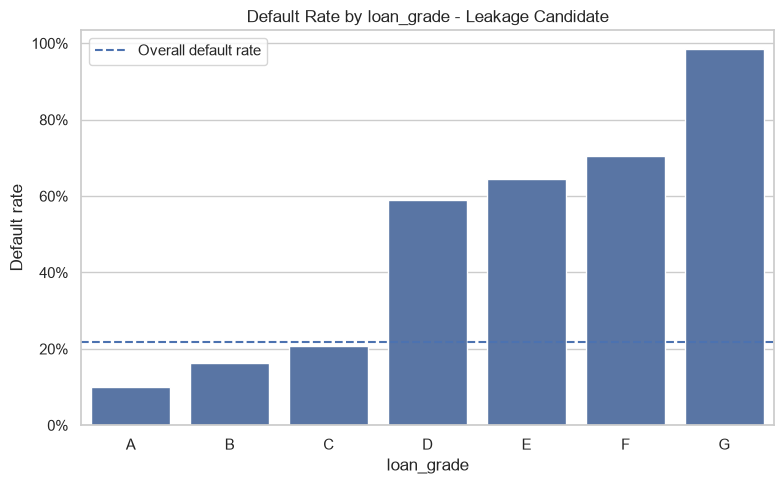


--- loan_int_rate by target ---


,loan_status,count,missing,mean,median,std,min,p25,p75,max
0,0,23001,2472,10.44,10.59,2.98,5.42,7.68,12.69,22.06
1,1,6464,644,13.06,13.49,3.29,5.42,10.74,15.58,23.22



Median gap (Default - Non-default): +2.90
Standardized median gap: +0.89


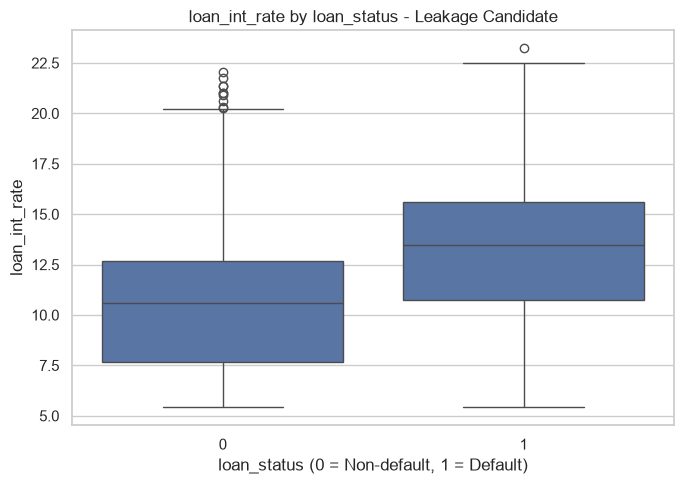


--- loan_int_rate quantile bins vs default rate ---


,loan_int_rate_bin,count,default_count,default_rate,row_share
0,"(5.419, 7.51]",6016,526,8.74%,20.42%
1,"(7.51, 10.25]",5988,809,13.51%,20.32%
2,"(10.25, 11.86]",5779,958,16.58%,19.61%
3,"(11.86, 13.92]",5814,1201,20.66%,19.73%
4,"(13.92, 23.22]",5868,2970,50.61%,19.92%



LEAKAGE SIGNAL SUMMARY


,column,signal_type,missing_rate,signal_value,signal_interpretation,primary_model_decision
0,loan_int_rate,numeric_median_gap_by_target,9.56%,+2.9000,Median(Default) - Median(Non-default) = +2.90; standardized gap = +0.89. A pricing variable with strong target separation may reflect prior risk assessment.,exclude_until_application_time_availability_is_confirmed
1,loan_grade,categorical_default_rate_spread,0.00%,+0.6058,Strong grade-level separation is expected if loan_grade is an underwriting output; this increases leakage concern rather than automatically approving feature use.,exclude_until_application_time_availability_is_confirmed



Leakage signal note:
Leakage candidates show EDA signal against target, especially if grade/rate were assigned after underwriting. This signal is audit evidence, not permission to use the variables in the Primary Feature Set. Primary baseline should exclude loan_grade and loan_int_rate until data provenance and application-time availability are confirmed. Extended experiments may include them only for ablation and leakage-risk comparison.


In [4]:
# 1.2 - Kiểm tra tín hiệu của leakage candidates ở mức EDA

# ============================================================
# 1. Kiểm tra input
# ============================================================

if "df_raw" not in globals():
    raise NameError("Chưa có df_raw. Hãy chạy cell 0.2 trước.")

if TARGET_COL not in df_raw.columns:
    raise KeyError(f"Không tìm thấy target column: {TARGET_COL}")

if "potential_leakage_cols" not in globals():
    potential_leakage_cols = [
        col for col in globals().get(
            "POTENTIAL_LEAKAGE_COLS",
            ["loan_grade", "loan_int_rate"],
        )
        if col in df_raw.columns
    ]

leakage_signal_cols = [
    col for col in potential_leakage_cols
    if col in df_raw.columns
]

if not leakage_signal_cols:
    raise ValueError("Không tìm thấy leakage candidate nào trong df_raw.")

valid_target_mask = df_raw[TARGET_COL].isin([0, 1])
valid_target_rows = int(valid_target_mask.sum())

if valid_target_rows == 0:
    raise ValueError("Không có target 0/1 hợp lệ để phân tích leakage signal.")

overall_default_rate = float(
    df_raw.loc[valid_target_mask, TARGET_COL].mean()
)

leakage_signal_tables = {}
leakage_signal_records = []

print("=" * 90)
print("LEAKAGE CANDIDATE SIGNAL CHECK - EDA ONLY")
print("=" * 90)
print(f"Candidate columns: {leakage_signal_cols}")
print(f"Overall default rate: {overall_default_rate:.2%}")

# ============================================================
# 2. loan_grade: default rate theo grade
# ============================================================

if "loan_grade" in leakage_signal_cols:
    grade_data = (
        df_raw.loc[valid_target_mask, ["loan_grade", TARGET_COL]]
        .copy()
    )

    grade_data["loan_grade"] = (
        grade_data["loan_grade"]
        .astype("string")
        .fillna("<Missing>")
    )

    loan_grade_signal_table = (
        grade_data
        .groupby("loan_grade", dropna=False)[TARGET_COL]
        .agg(
            count="size",
            default_count="sum",
            default_rate="mean",
        )
        .reset_index()
    )

    loan_grade_signal_table["row_share"] = (
        loan_grade_signal_table["count"]
        / valid_target_rows
    )

    loan_grade_signal_table["default_rate_gap"] = (
        loan_grade_signal_table["default_rate"]
        - overall_default_rate
    )

    loan_grade_signal_table = (
        loan_grade_signal_table
        .sort_values("loan_grade")
        .reset_index(drop=True)
    )

    reliable_grade_table = loan_grade_signal_table.loc[
        loan_grade_signal_table["count"] >= 100
    ]

    if len(reliable_grade_table) >= 2:
        grade_default_rate_spread = float(
            reliable_grade_table["default_rate"].max()
            - reliable_grade_table["default_rate"].min()
        )
    else:
        grade_default_rate_spread = np.nan

    leakage_signal_tables["loan_grade"] = loan_grade_signal_table

    leakage_signal_records.append({
        "column": "loan_grade",
        "signal_type": "categorical_default_rate_spread",
        "missing_rate": float(df_raw["loan_grade"].isna().mean()),
        "signal_value": grade_default_rate_spread,
        "signal_interpretation": (
            "Strong grade-level separation is expected if loan_grade is an underwriting output; "
            "this increases leakage concern rather than automatically approving feature use."
        ),
        "primary_model_decision": "exclude_until_application_time_availability_is_confirmed",
    })

    print("\n--- loan_grade default rate by grade ---")
    display(
        loan_grade_signal_table.style.format({
            "row_share": "{:.2%}",
            "default_rate": "{:.2%}",
            "default_rate_gap": "{:+.2%}",
        })
    )

    fig, ax = plt.subplots(figsize=(8, 5))
    sns.barplot(
        data=loan_grade_signal_table,
        x="loan_grade",
        y="default_rate",
        ax=ax,
    )
    ax.axhline(
        overall_default_rate,
        linestyle="--",
        linewidth=1.5,
        label="Overall default rate",
    )
    ax.set_title("Default Rate by loan_grade - Leakage Candidate")
    ax.set_xlabel("loan_grade")
    ax.set_ylabel("Default rate")
    ax.yaxis.set_major_formatter(
        plt.FuncFormatter(lambda y, _: f"{y:.0%}")
    )
    ax.legend()
    plt.tight_layout()
    plt.show()

# ============================================================
# 3. loan_int_rate: phân phối theo target
# ============================================================

if "loan_int_rate" in leakage_signal_cols:
    rate_data = (
        df_raw.loc[valid_target_mask, ["loan_int_rate", TARGET_COL]]
        .copy()
    )

    loan_int_rate_signal_table = (
        rate_data
        .groupby(TARGET_COL)["loan_int_rate"]
        .agg(
            count="count",
            missing=lambda series: int(series.isna().sum()),
            mean="mean",
            median="median",
            std="std",
            min="min",
            p25=lambda series: series.quantile(0.25),
            p75=lambda series: series.quantile(0.75),
            max="max",
        )
        .reset_index()
    )

    non_default_rate_values = rate_data.loc[
        rate_data[TARGET_COL].eq(0),
        "loan_int_rate",
    ].dropna()

    default_rate_values = rate_data.loc[
        rate_data[TARGET_COL].eq(1),
        "loan_int_rate",
    ].dropna()

    if not non_default_rate_values.empty and not default_rate_values.empty:
        median_non_default = float(non_default_rate_values.median())
        median_default = float(default_rate_values.median())
        rate_median_gap = median_default - median_non_default

        pooled_std = float(rate_data["loan_int_rate"].std(skipna=True))
        standardized_rate_gap = (
            rate_median_gap / pooled_std
            if pooled_std and pd.notna(pooled_std)
            else np.nan
        )
    else:
        median_non_default = np.nan
        median_default = np.nan
        rate_median_gap = np.nan
        standardized_rate_gap = np.nan

    leakage_signal_tables["loan_int_rate"] = loan_int_rate_signal_table

    leakage_signal_records.append({
        "column": "loan_int_rate",
        "signal_type": "numeric_median_gap_by_target",
        "missing_rate": float(df_raw["loan_int_rate"].isna().mean()),
        "signal_value": rate_median_gap,
        "signal_interpretation": (
            f"Median(Default) - Median(Non-default) = {rate_median_gap:+.2f}; "
            f"standardized gap = {standardized_rate_gap:+.2f}. "
            "A pricing variable with strong target separation may reflect prior risk assessment."
        ),
        "primary_model_decision": "exclude_until_application_time_availability_is_confirmed",
    })

    print("\n--- loan_int_rate by target ---")
    display(
        loan_int_rate_signal_table.style.format({
            "mean": "{:.2f}",
            "median": "{:.2f}",
            "std": "{:.2f}",
            "min": "{:.2f}",
            "p25": "{:.2f}",
            "p75": "{:.2f}",
            "max": "{:.2f}",
        })
    )

    print(
        "\nMedian gap "
        "(Default - Non-default): "
        f"{rate_median_gap:+.2f}"
    )
    print(f"Standardized median gap: {standardized_rate_gap:+.2f}")

    fig, ax = plt.subplots(figsize=(7, 5))
    sns.boxplot(
        data=rate_data,
        x=TARGET_COL,
        y="loan_int_rate",
        ax=ax,
    )
    ax.set_title("loan_int_rate by loan_status - Leakage Candidate")
    ax.set_xlabel("loan_status (0 = Non-default, 1 = Default)")
    ax.set_ylabel("loan_int_rate")
    plt.tight_layout()
    plt.show()

    rate_bin_data = rate_data.dropna(subset=["loan_int_rate"]).copy()

    if rate_bin_data["loan_int_rate"].nunique() >= 4:
        rate_bin_data["loan_int_rate_bin"] = pd.qcut(
            rate_bin_data["loan_int_rate"],
            q=5,
            duplicates="drop",
        )

        loan_int_rate_bin_table = (
            rate_bin_data
            .groupby("loan_int_rate_bin", observed=True)[TARGET_COL]
            .agg(
                count="size",
                default_count="sum",
                default_rate="mean",
            )
            .reset_index()
        )

        loan_int_rate_bin_table["row_share"] = (
            loan_int_rate_bin_table["count"]
            / len(rate_bin_data)
        )

        leakage_signal_tables["loan_int_rate_bins"] = loan_int_rate_bin_table

        print("\n--- loan_int_rate quantile bins vs default rate ---")
        display(
            loan_int_rate_bin_table.style.format({
                "row_share": "{:.2%}",
                "default_rate": "{:.2%}",
            })
        )

# ============================================================
# 4. Summary và note
# ============================================================

leakage_signal_summary = pd.DataFrame(leakage_signal_records)

if not leakage_signal_summary.empty:
    leakage_signal_summary["abs_signal_value"] = (
        leakage_signal_summary["signal_value"]
        .abs()
    )
    leakage_signal_summary = (
        leakage_signal_summary
        .sort_values("abs_signal_value", ascending=False, na_position="last")
        .drop(columns="abs_signal_value")
        .reset_index(drop=True)
    )

leakage_signal_note = (
    "Leakage candidates show EDA signal against target, especially if grade/rate "
    "were assigned after underwriting. This signal is audit evidence, not permission "
    "to use the variables in the Primary Feature Set. Primary baseline should exclude "
    "loan_grade and loan_int_rate until data provenance and application-time "
    "availability are confirmed. Extended experiments may include them only for "
    "ablation and leakage-risk comparison."
)

print("\n" + "=" * 90)
print("LEAKAGE SIGNAL SUMMARY")
print("=" * 90)

display(
    leakage_signal_summary.style.format({
        "missing_rate": "{:.2%}",
        "signal_value": "{:+.4f}",
    })
)

print("\nLeakage signal note:")
print(leakage_signal_note)

## Section 2 - Feature Set Design

Cần tạo hai bộ biến:

- **Primary Feature Set:** chỉ gồm application-time features, dùng cho model chính.
- **Extended Feature Set:** có thể thêm biến rủi ro leakage để so sánh/giải thích, nhưng không dùng làm baseline chính nếu chưa xác minh.

In [5]:
# 2.1 - Tạo Primary Feature Set

if "leakage_review" not in globals():
    raise NameError("Chưa có leakage_review. Hãy chạy cell 1.1 trước.")

primary_feature_cols = leakage_review.loc[
    leakage_review["include_primary"],
    "column",
].tolist()

primary_excluded_cols = (
    leakage_review
    .loc[
        ~leakage_review["include_primary"],
        ["column", "role", "leakage_risk", "reason"],
    ]
    .rename(columns={"reason": "exclude_reason"})
    .reset_index(drop=True)
)

redundancy_decision = pd.DataFrame([
    {
        "redundant_pair": "loan_percent_income vs loan_to_income_ratio",
        "decision": "keep loan_to_income_ratio; exclude loan_percent_income from Primary",
        "reason": (
            "EDA showed near-perfect redundancy. Keeping one LTI definition improves "
            "interpretability and reduces duplicate information."
        ),
    }
])

for forbidden_col in [TARGET_COL, ID_COL, "loan_percent_income"]:
    if forbidden_col in primary_feature_cols:
        raise AssertionError(f"{forbidden_col} không được nằm trong primary_feature_cols.")

primary_leakage_overlap = sorted(set(primary_feature_cols) & set(potential_leakage_cols))
primary_proxy_overlap = sorted(set(primary_feature_cols) & set(sensitive_or_proxy_cols))

if primary_leakage_overlap:
    raise AssertionError("Primary vẫn chứa leakage candidates: " + ", ".join(primary_leakage_overlap))

if primary_proxy_overlap:
    raise AssertionError("Primary vẫn chứa sensitive/proxy columns: " + ", ".join(primary_proxy_overlap))

primary_feature_set_note = (
    f"Primary Feature Set has {len(primary_feature_cols)} features. "
    "It excludes target, identifier, high-risk leakage candidates, audit-only proxy variables, "
    "and loan_percent_income because loan_to_income_ratio is the chosen LTI representation."
)

print("=" * 90)
print("PRIMARY FEATURE SET")
print("=" * 90)
print(f"Primary feature count: {len(primary_feature_cols)}")
print(f"Primary leakage overlap: {primary_leakage_overlap}")
print(f"Primary proxy overlap: {primary_proxy_overlap}")

print("\n--- Redundancy decision ---")
display(redundancy_decision)

print("\n--- primary_feature_cols ---")
print(primary_feature_cols)

print("\n--- primary_excluded_cols ---")
display(primary_excluded_cols)

print("\nPrimary feature set note:")
print(primary_feature_set_note)

PRIMARY FEATURE SET
Primary feature count: 18
Primary leakage overlap: []
Primary proxy overlap: []

--- Redundancy decision ---


,redundant_pair,decision,reason
0,loan_percent_income vs loan_to_income_ratio,keep loan_to_income_ratio; exclude loan_percen...,EDA showed near-perfect redundancy. Keeping on...



--- primary_feature_cols ---
['cb_person_cred_hist_length', 'cb_person_default_on_file', 'credit_utilization_ratio', 'debt_to_income_ratio', 'education_level', 'employment_type', 'loan_amnt', 'loan_intent', 'loan_term_months', 'loan_to_income_ratio', 'marital_status', 'open_accounts', 'other_debt', 'past_delinquencies', 'person_age', 'person_emp_length', 'person_home_ownership', 'person_income']

--- primary_excluded_cols ---


,column,role,leakage_risk,exclude_reason
0,loan_grade,potential_post_underwriting,high,Potential post-underwriting grade. It may enco...
1,loan_int_rate,potential_post_underwriting,high,Potential post-underwriting pricing variable. ...
2,city,audit_only_sensitive_or_proxy,policy_review,High-cardinality geographic proxy; keep for fa...
3,city_latitude,audit_only_sensitive_or_proxy,policy_review,Continuous geographic proxy; keep for fairness...
4,city_longitude,audit_only_sensitive_or_proxy,policy_review,Continuous geographic proxy; keep for fairness...
5,country,audit_only_sensitive_or_proxy,policy_review,Geographic proxy; keep for fairness/proxy audi...
6,gender,audit_only_sensitive_or_proxy,policy_review,Sensitive attribute; keep for fairness audit o...
7,state,audit_only_sensitive_or_proxy,policy_review,Geographic proxy; keep for fairness/proxy audi...
8,loan_percent_income,redundant_derived_feature,redundancy_review,Excluded from Primary because loan_percent_inc...
9,client_ID,identifier,not_feature,Identifier can let the model memorize rows and...



Primary feature set note:
Primary Feature Set has 18 features. It excludes target, identifier, high-risk leakage candidates, audit-only proxy variables, and loan_percent_income because loan_to_income_ratio is the chosen LTI representation.


In [6]:
# 2.2 - Tạo Extended Feature Set và Audit-only Variables

if "primary_feature_cols" not in globals():
    raise NameError("Chưa có primary_feature_cols. Hãy chạy cell 2.1 trước.")

extended_feature_cols = [
    *primary_feature_cols,
    *[
        col for col in potential_leakage_cols
        if col in df_raw.columns and col not in primary_feature_cols
    ],
]

extended_only_cols = [
    col for col in extended_feature_cols
    if col not in primary_feature_cols
]

audit_only_cols = [
    col for col in sensitive_or_proxy_cols
    if col in df_raw.columns
]

primary_not_in_extended = sorted(set(primary_feature_cols) - set(extended_feature_cols))

if primary_not_in_extended:
    raise AssertionError("Primary không phải subset của Extended: " + ", ".join(primary_not_in_extended))

unexpected_extended_proxy_cols = sorted(set(extended_feature_cols) & set(audit_only_cols))

if unexpected_extended_proxy_cols:
    raise AssertionError(
        "Extended không được chứa audit-only proxy variables: "
        + ", ".join(unexpected_extended_proxy_cols)
    )

extended_only_detail = (
    leakage_review
    .loc[
        leakage_review["column"].isin(extended_only_cols),
        ["column", "role", "leakage_risk", "availability_assumption", "reason"],
    ]
    .reset_index(drop=True)
)

audit_only_detail = (
    leakage_review
    .loc[
        leakage_review["column"].isin(audit_only_cols),
        ["column", "role", "leakage_risk", "reason"],
    ]
    .reset_index(drop=True)
)

feature_set_summary = pd.DataFrame([
    {
        "feature_set": "primary",
        "feature_count": len(primary_feature_cols),
        "intended_use": "Main baseline and champion-model candidate.",
        "columns_added_vs_primary": [],
        "notes": primary_feature_set_note,
    },
    {
        "feature_set": "extended",
        "feature_count": len(extended_feature_cols),
        "intended_use": "Leakage ablation only: Primary + loan_grade + loan_int_rate if available.",
        "columns_added_vs_primary": extended_only_cols,
        "notes": "Do not treat Extended as production-ready without data provenance proof.",
    },
    {
        "feature_set": "audit_only",
        "feature_count": len(audit_only_cols),
        "intended_use": "Fairness/proxy audit only, not training inputs.",
        "columns_added_vs_primary": audit_only_cols,
        "notes": "Keep sensitive/geographic variables outside primary and extended modeling sets.",
    },
])

extended_feature_set_note = (
    f"Extended Feature Set has {len(extended_feature_cols)} features and adds only "
    f"{', '.join(extended_only_cols) if extended_only_cols else 'no leakage candidates'} to Primary. "
    f"Audit-only columns are separated: {', '.join(audit_only_cols) if audit_only_cols else 'None'}."
)

print("=" * 90)
print("EXTENDED FEATURE SET AND AUDIT-ONLY VARIABLES")
print("=" * 90)

print("\n--- extended_feature_cols ---")
print(extended_feature_cols)

print("\n--- extended_only_cols ---")
print(extended_only_cols)

print("\n--- audit_only_cols ---")
print(audit_only_cols)

print("\n--- extended_only_detail ---")
display(extended_only_detail)

print("\n--- audit_only_detail ---")
display(audit_only_detail)

print("\n--- feature_set_summary ---")
display(feature_set_summary)

print("\nExtended feature set note:")
print(extended_feature_set_note)

EXTENDED FEATURE SET AND AUDIT-ONLY VARIABLES

--- extended_feature_cols ---
['cb_person_cred_hist_length', 'cb_person_default_on_file', 'credit_utilization_ratio', 'debt_to_income_ratio', 'education_level', 'employment_type', 'loan_amnt', 'loan_intent', 'loan_term_months', 'loan_to_income_ratio', 'marital_status', 'open_accounts', 'other_debt', 'past_delinquencies', 'person_age', 'person_emp_length', 'person_home_ownership', 'person_income', 'loan_grade', 'loan_int_rate']

--- extended_only_cols ---
['loan_grade', 'loan_int_rate']

--- audit_only_cols ---
['gender', 'country', 'state', 'city', 'city_latitude', 'city_longitude']

--- extended_only_detail ---


,column,role,leakage_risk,availability_assumption,reason
0,loan_grade,potential_post_underwriting,high,Unknown or likely after underwriting/risk asse...,Potential post-underwriting grade. It may enco...
1,loan_int_rate,potential_post_underwriting,high,Unknown or likely after underwriting/risk asse...,Potential post-underwriting pricing variable. ...



--- audit_only_detail ---


,column,role,leakage_risk,reason
0,city,audit_only_sensitive_or_proxy,policy_review,High-cardinality geographic proxy; keep for fa...
1,city_latitude,audit_only_sensitive_or_proxy,policy_review,Continuous geographic proxy; keep for fairness...
2,city_longitude,audit_only_sensitive_or_proxy,policy_review,Continuous geographic proxy; keep for fairness...
3,country,audit_only_sensitive_or_proxy,policy_review,Geographic proxy; keep for fairness/proxy audi...
4,gender,audit_only_sensitive_or_proxy,policy_review,Sensitive attribute; keep for fairness audit o...
5,state,audit_only_sensitive_or_proxy,policy_review,Geographic proxy; keep for fairness/proxy audi...



--- feature_set_summary ---


,feature_set,feature_count,intended_use,columns_added_vs_primary,notes
0,primary,18,Main baseline and champion-model candidate.,[],Primary Feature Set has 18 features. It exclud...
1,extended,20,Leakage ablation only: Primary + loan_grade + ...,"[loan_grade, loan_int_rate]",Do not treat Extended as production-ready with...
2,audit_only,6,"Fairness/proxy audit only, not training inputs.","[gender, country, state, city, city_latitude, ...",Keep sensitive/geographic variables outside pr...



Extended feature set note:
Extended Feature Set has 20 features and adds only loan_grade, loan_int_rate to Primary. Audit-only columns are separated: gender, country, state, city, city_latitude, city_longitude.


## Section 3 - Preprocessing Design

Thiết kế preprocessing trước khi code pipeline chính thức.

Cần ghi rõ:
- Numeric xử lý missing/outlier/scaling thế nào.
- Categorical encoding thế nào.
- Missing indicator nào nên thử.
- Logic nào phải nằm trong train/CV pipeline để tránh leakage.

In [7]:
# 3.1 - Phân loại feature theo preprocessing type

# ============================================================
# 1. Chọn feature set mặc định cho preprocessing design
# ============================================================

if "primary_feature_cols" not in globals():
    raise NameError("Chưa có primary_feature_cols. Hãy chạy cell 2.1 trước.")

PREPROCESSING_FEATURE_SET_NAME = "primary"
preprocessing_feature_cols = primary_feature_cols.copy()

if not preprocessing_feature_cols:
    raise ValueError("preprocessing_feature_cols đang rỗng.")

# ============================================================
# 2. Phân nhóm theo kiểu xử lý
# ============================================================

numeric_preprocess_cols = (
    df_raw[preprocessing_feature_cols]
    .select_dtypes(include=[np.number])
    .columns
    .tolist()
)

categorical_preprocess_cols = [
    col for col in preprocessing_feature_cols
    if col not in numeric_preprocess_cols
]

binary_candidate_cols = [
    col for col in categorical_preprocess_cols
    if df_raw[col].nunique(dropna=True) == 2
]

ordinal_candidate_cols = [
    col for col in [
        "education_level",
    ]
    if col in preprocessing_feature_cols
]

geographic_candidate_cols = [
    col for col in preprocessing_feature_cols
    if col in [
        "country",
        "state",
        "city",
        "city_latitude",
        "city_longitude",
    ]
]

nominal_categorical_cols = [
    col for col in categorical_preprocess_cols
    if col not in binary_candidate_cols
    and col not in ordinal_candidate_cols
]

preprocessing_group_records = [
    {
        "group": "numeric_preprocess_cols",
        "count": len(numeric_preprocess_cols),
        "columns": numeric_preprocess_cols,
        "recommended_transform": "median imputation, optional robust scaling/log transform after CV check",
    },
    {
        "group": "categorical_preprocess_cols",
        "count": len(categorical_preprocess_cols),
        "columns": categorical_preprocess_cols,
        "recommended_transform": "most-frequent or explicit Missing imputation, then one-hot/target-safe encoding",
    },
    {
        "group": "binary_candidate_cols",
        "count": len(binary_candidate_cols),
        "columns": binary_candidate_cols,
        "recommended_transform": "binary mapping inside pipeline",
    },
    {
        "group": "ordinal_candidate_cols",
        "count": len(ordinal_candidate_cols),
        "columns": ordinal_candidate_cols,
        "recommended_transform": "ordinal mapping only when category order is defensible",
    },
    {
        "group": "geographic_candidate_cols",
        "count": len(geographic_candidate_cols),
        "columns": geographic_candidate_cols,
        "recommended_transform": "excluded from primary by policy; audit separately if present",
    },
]

preprocessing_group_summary = pd.DataFrame(preprocessing_group_records)

preprocessing_design_note = (
    f"Preprocessing design uses the {PREPROCESSING_FEATURE_SET_NAME} feature set: "
    f"{len(numeric_preprocess_cols)} numeric and "
    f"{len(categorical_preprocess_cols)} categorical features."
)

# ============================================================
# 3. Display
# ============================================================

print("=" * 90)
print("PREPROCESSING FEATURE GROUPS")
print("=" * 90)
print(preprocessing_design_note)

display(preprocessing_group_summary)

PREPROCESSING FEATURE GROUPS
Preprocessing design uses the primary feature set: 12 numeric and 6 categorical features.


,group,count,columns,recommended_transform
0,numeric_preprocess_cols,12,"[cb_person_cred_hist_length, credit_utilizatio...","median imputation, optional robust scaling/log..."
1,categorical_preprocess_cols,6,"[cb_person_default_on_file, education_level, e...","most-frequent or explicit Missing imputation, ..."
2,binary_candidate_cols,1,[cb_person_default_on_file],binary mapping inside pipeline
3,ordinal_candidate_cols,1,[education_level],ordinal mapping only when category order is de...
4,geographic_candidate_cols,0,[],excluded from primary by policy; audit separat...


In [8]:
# 3.2 - Missing handling design

# ============================================================
# 1. Tạo missing plan trên các feature được review
# ============================================================

if "extended_feature_cols" not in globals():
    raise NameError("Chưa có extended_feature_cols. Hãy chạy cell 2.2 trước.")

missing_plan_cols = [
    col for col in extended_feature_cols
    if df_raw[col].isna().any()
]

missing_preprocessing_records = []

for column in missing_plan_cols:
    missing_count = int(df_raw[column].isna().sum())
    missing_rate = float(df_raw[column].isna().mean())
    is_numeric = pd.api.types.is_numeric_dtype(df_raw[column])
    in_primary = column in primary_feature_cols
    in_extended = column in extended_feature_cols
    is_leakage_candidate = column in potential_leakage_cols

    if is_numeric:
        candidate_methods = "median_imputation; optional_missing_indicator"
        recommended_method = "median_imputation_inside_pipeline"
    else:
        candidate_methods = "most_frequent_imputation; explicit_missing_category"
        recommended_method = "explicit_missing_category_inside_pipeline"

    add_missing_indicator = (
        missing_rate >= 0.01
        or column in ["person_emp_length", "loan_int_rate"]
    )

    if column == "person_emp_length":
        reason = (
            "Employment length has missing values and business meaning; median imputation "
            "plus a missing indicator should be validated."
        )
    elif column == "loan_int_rate":
        reason = (
            "Interest rate has missing values and high leakage risk. Exclude from primary; "
            "if used in extended experiments, impute inside the pipeline and keep a missing indicator."
        )
    elif is_leakage_candidate:
        reason = (
            "Leakage candidate with missing values; handle only in extended experiments "
            "until availability is confirmed."
        )
    else:
        reason = (
            "Missing values must be handled after train/validation split to avoid leakage "
            "from global statistics."
        )

    missing_preprocessing_records.append({
        "column": column,
        "dtype": str(df_raw[column].dtype),
        "missing_count": missing_count,
        "missing_rate": missing_rate,
        "in_primary": in_primary,
        "in_extended": in_extended,
        "candidate_methods": candidate_methods,
        "recommended_method": recommended_method,
        "add_missing_indicator": add_missing_indicator,
        "reason": reason,
    })

missing_preprocessing_plan = pd.DataFrame(missing_preprocessing_records)

if not missing_preprocessing_plan.empty:
    missing_preprocessing_plan = (
        missing_preprocessing_plan
        .sort_values(["in_primary", "missing_rate"], ascending=[False, False])
        .reset_index(drop=True)
    )

missing_strategy_note = (
    "Missing handling is a design decision only here. Actual imputers and missing "
    "indicators must be fitted inside train/CV pipelines, never on the full df_raw."
)

# ============================================================
# 2. Display
# ============================================================

print("=" * 90)
print("MISSING HANDLING DESIGN")
print("=" * 90)

if missing_preprocessing_plan.empty:
    print("Không có feature nào trong extended_feature_cols bị missing.")
else:
    display(
        missing_preprocessing_plan.style.format({
            "missing_rate": "{:.2%}",
        })
    )

print("\nMissing strategy note:")
print(missing_strategy_note)

MISSING HANDLING DESIGN


,column,dtype,missing_count,missing_rate,in_primary,in_extended,candidate_methods,recommended_method,add_missing_indicator,reason
0,person_emp_length,float64,895,2.75%,True,True,median_imputation; optional_missing_indicator,median_imputation_inside_pipeline,True,Employment length has missing values and business meaning; median imputation plus a missing indicator should be validated.
1,loan_int_rate,float64,3116,9.56%,False,True,median_imputation; optional_missing_indicator,median_imputation_inside_pipeline,True,"Interest rate has missing values and high leakage risk. Exclude from primary; if used in extended experiments, impute inside the pipeline and keep a missing indicator."



Missing strategy note:
Missing handling is a design decision only here. Actual imputers and missing indicators must be fitted inside train/CV pipelines, never on the full df_raw.


In [9]:
# 3.3 - Outlier handling design

# ============================================================
# 1. Business-rule checks chưa áp dụng vào dữ liệu
# ============================================================

outlier_rules = [
    {
        "column": "person_age",
        "rule_name": "age_outside_plausible_range",
        "business_rule": "20 <= person_age <= 100",
        "candidate_treatment": "source_review_then_drop_or_cap_only_if_confirmed_error",
        "reason": "Age outside plausible range is likely a data-quality issue.",
    },
    {
        "column": "person_emp_length",
        "rule_name": "employment_length_inconsistent_with_age",
        "business_rule": "person_emp_length <= person_age - 14",
        "candidate_treatment": "set_invalid_emp_length_to_missing_then_impute_inside_pipeline",
        "reason": "Employment length should not exceed plausible years since working age.",
    },
    {
        "column": "person_income",
        "rule_name": "income_extreme_right_tail",
        "business_rule": "review high-end tail with robust model or log transform",
        "candidate_treatment": "no_drop_by_default; consider_log1p_or_winsorization_after_cv",
        "reason": "Income commonly has a long right tail; avoid arbitrary clipping during EDA.",
    },
    {
        "column": "loan_amnt",
        "rule_name": "loan_amount_extreme_right_tail",
        "business_rule": "review high-end tail relative to income",
        "candidate_treatment": "prefer_ratio_features_and_robust_scaling_over_manual_drop",
        "reason": "Loan amount is meaningful only with borrower income and debt context.",
    },
]

outlier_records = []

for rule in outlier_rules:
    column = rule["column"]

    if column not in df_raw.columns:
        affected_rows = np.nan
        affected_rate = np.nan
        available = False

    elif rule["rule_name"] == "age_outside_plausible_range":
        mask = (
            df_raw[column].notna()
            & ~df_raw[column].between(20, 100, inclusive="both")
        )
        affected_rows = int(mask.sum())
        affected_rate = float(mask.mean())
        available = True

    elif rule["rule_name"] == "employment_length_inconsistent_with_age":
        if "person_age" in df_raw.columns:
            mask = (
                df_raw["person_age"].notna()
                & df_raw[column].notna()
                & df_raw["person_age"].between(20, 100, inclusive="both")
                & (df_raw[column] > (df_raw["person_age"] - 14))
            )
            affected_rows = int(mask.sum())
            affected_rate = float(mask.mean())
            available = True
        else:
            affected_rows = np.nan
            affected_rate = np.nan
            available = False

    else:
        series = df_raw[column].dropna()
        if series.empty:
            affected_rows = 0
            affected_rate = 0.0
        else:
            p99 = series.quantile(0.99)
            mask = df_raw[column].gt(p99)
            affected_rows = int(mask.sum())
            affected_rate = float(mask.mean())
        available = True

    outlier_records.append({
        **rule,
        "available_in_data": available,
        "affected_rows": affected_rows,
        "affected_rate": affected_rate,
        "apply_in_notebook": False,
    })

outlier_preprocessing_plan = pd.DataFrame(outlier_records)
outlier_rule_summary = outlier_preprocessing_plan.copy()

outlier_strategy_note = (
    "Outlier handling is not applied in this notebook. Business-rule corrections "
    "should be documented and implemented in preprocessing functions so training, "
    "validation, test, and production scoring use the same logic."
)

# ============================================================
# 2. Display
# ============================================================

print("=" * 90)
print("OUTLIER HANDLING DESIGN")
print("=" * 90)

display(
    outlier_preprocessing_plan.style.format({
        "affected_rate": "{:.3%}",
    })
)

print("\nOutlier strategy note:")
print(outlier_strategy_note)

OUTLIER HANDLING DESIGN


,column,rule_name,business_rule,candidate_treatment,reason,available_in_data,affected_rows,affected_rate,apply_in_notebook
0,person_age,age_outside_plausible_range,20 <= person_age <= 100,source_review_then_drop_or_cap_only_if_confirmed_error,Age outside plausible range is likely a data-quality issue.,True,5,0.015%,False
1,person_emp_length,employment_length_inconsistent_with_age,person_emp_length <= person_age - 14,set_invalid_emp_length_to_missing_then_impute_inside_pipeline,Employment length should not exceed plausible years since working age.,True,2,0.006%,False
2,person_income,income_extreme_right_tail,review high-end tail with robust model or log transform,no_drop_by_default; consider_log1p_or_winsorization_after_cv,Income commonly has a long right tail; avoid arbitrary clipping during EDA.,True,326,1.001%,False
3,loan_amnt,loan_amount_extreme_right_tail,review high-end tail relative to income,prefer_ratio_features_and_robust_scaling_over_manual_drop,Loan amount is meaningful only with borrower income and debt context.,True,324,0.994%,False



Outlier strategy note:
Outlier handling is not applied in this notebook. Business-rule corrections should be documented and implemented in preprocessing functions so training, validation, test, and production scoring use the same logic.


## Section 4 - Feature Engineering Candidates

Chỉ tạo feature có lý do nghiệp vụ. Ưu tiên ít nhưng chắc:
- Debt burden.
- Affordability.
- Credit history / delinquency signals.
- Employment stability.
- Interactions có ý nghĩa.

In [10]:
# 4.1 - Thiết kế candidate ratio features

ratio_candidate_specs = [
    {
        "feature_name": "loan_to_income_ratio",
        "formula": "loan_amnt / person_income",
        "required_columns": ["loan_amnt", "person_income"],
        "business_meaning": "Chosen LTI representation for requested loan burden.",
        "definition_status": "selected_existing_raw_feature",
    },
    {
        "feature_name": "existing_debt_to_income_ratio",
        "formula": "other_debt / person_income",
        "required_columns": ["other_debt", "person_income"],
        "business_meaning": "Existing debt burden before adding requested loan.",
        "definition_status": "new_feature_with_distinct_name",
    },
    {
        "feature_name": "total_debt_to_income_ratio",
        "formula": "(other_debt + loan_amnt) / person_income",
        "required_columns": ["other_debt", "loan_amnt", "person_income"],
        "business_meaning": "Total debt burden including requested loan.",
        "definition_status": "new_feature_do_not_confuse_with_existing_dti",
    },
    {
        "feature_name": "loan_amount_per_month",
        "formula": "loan_amnt / loan_term_months",
        "required_columns": ["loan_amnt", "loan_term_months"],
        "business_meaning": "Simple monthly principal burden proxy.",
        "definition_status": "new_feature",
    },
    {
        "feature_name": "income_per_open_account",
        "formula": "person_income / open_accounts",
        "required_columns": ["person_income", "open_accounts"],
        "business_meaning": "Income support per active credit account.",
        "definition_status": "new_feature",
    },
]

ratio_feature_candidates = pd.DataFrame(ratio_candidate_specs)
ratio_feature_candidates["raw_exists"] = ratio_feature_candidates["feature_name"].isin(df_raw.columns)
ratio_feature_candidates["required_columns_available"] = ratio_feature_candidates["required_columns"].apply(
    lambda cols: all(col in df_raw.columns for col in cols)
)
ratio_feature_candidates["include_candidate"] = ratio_feature_candidates["required_columns_available"]
ratio_feature_candidates["implementation_note"] = np.where(
    ratio_feature_candidates["raw_exists"],
    "Already present in raw data; keep the existing project definition and do not recompute under another meaning.",
    "Create inside src/features/build_features.py with division-by-zero guards.",
)

selected_ratio_feature_candidates = (
    ratio_feature_candidates.loc[ratio_feature_candidates["include_candidate"], "feature_name"].tolist()
)

dti_definition_note = (
    "Do not redefine debt_to_income_ratio as other_debt / income. If existing-debt-only ratio is needed, "
    "use existing_debt_to_income_ratio. Keep debt_to_income_ratio as the project-level DTI definition."
)

ratio_feature_note = (
    "Ratio features are business-readable risk indicators and must be created consistently inside the feature pipeline."
)

print("=" * 90)
print("RATIO FEATURE CANDIDATES")
print("=" * 90)
display(ratio_feature_candidates)

print("\nSelected ratio feature candidates:")
print(selected_ratio_feature_candidates)

print("\nDTI definition note:")
print(dti_definition_note)

print("\nRatio feature note:")
print(ratio_feature_note)

RATIO FEATURE CANDIDATES


,feature_name,formula,required_columns,business_meaning,definition_status,raw_exists,required_columns_available,include_candidate,implementation_note
0,loan_to_income_ratio,loan_amnt / person_income,"[loan_amnt, person_income]",Chosen LTI representation for requested loan b...,selected_existing_raw_feature,True,True,True,Already present in raw data; keep the existing...
1,existing_debt_to_income_ratio,other_debt / person_income,"[other_debt, person_income]",Existing debt burden before adding requested l...,new_feature_with_distinct_name,False,True,True,Create inside src/features/build_features.py w...
2,total_debt_to_income_ratio,(other_debt + loan_amnt) / person_income,"[other_debt, loan_amnt, person_income]",Total debt burden including requested loan.,new_feature_do_not_confuse_with_existing_dti,False,True,True,Create inside src/features/build_features.py w...
3,loan_amount_per_month,loan_amnt / loan_term_months,"[loan_amnt, loan_term_months]",Simple monthly principal burden proxy.,new_feature,False,True,True,Create inside src/features/build_features.py w...
4,income_per_open_account,person_income / open_accounts,"[person_income, open_accounts]",Income support per active credit account.,new_feature,False,True,True,Create inside src/features/build_features.py w...



Selected ratio feature candidates:
['loan_to_income_ratio', 'existing_debt_to_income_ratio', 'total_debt_to_income_ratio', 'loan_amount_per_month', 'income_per_open_account']

DTI definition note:
Do not redefine debt_to_income_ratio as other_debt / income. If existing-debt-only ratio is needed, use existing_debt_to_income_ratio. Keep debt_to_income_ratio as the project-level DTI definition.

Ratio feature note:
Ratio features are business-readable risk indicators and must be created consistently inside the feature pipeline.


In [11]:
# 4.2 - Thiết kế stability và risk flag features

flag_candidate_specs = [
    {
        "feature_name": "high_loan_to_income_flag",
        "source_columns": ["loan_to_income_ratio"],
        "rule": "loan_to_income_ratio >= 0.35",
        "threshold_source": "EDA/business heuristic; tune inside CV only",
        "business_meaning": "Requested loan is high compared with income.",
    },
    {
        "feature_name": "high_debt_to_income_flag",
        "source_columns": ["debt_to_income_ratio"],
        "rule": "debt_to_income_ratio >= 0.40",
        "threshold_source": "EDA/business heuristic; tune inside CV only",
        "business_meaning": "Project-level DTI is high; do not use existing-debt-only formula here.",
    },
    {
        "feature_name": "high_existing_debt_to_income_flag",
        "source_columns": ["existing_debt_to_income_ratio"],
        "rule": "existing_debt_to_income_ratio >= 0.30",
        "threshold_source": "Optional engineered feature threshold; validate inside CV",
        "business_meaning": "Existing debt burden is high before the requested loan.",
    },
    {
        "feature_name": "previous_default_flag",
        "source_columns": ["cb_person_default_on_file"],
        "rule": "cb_person_default_on_file == 'Y'",
        "threshold_source": "Raw binary credit-history field",
        "business_meaning": "Borrower has previous default on file.",
    },
    {
        "feature_name": "past_delinquency_flag",
        "source_columns": ["past_delinquencies"],
        "rule": "past_delinquencies > 0",
        "threshold_source": "Raw count field threshold at any delinquency",
        "business_meaning": "Borrower has at least one past delinquency.",
    },
    {
        "feature_name": "thin_credit_history_flag",
        "source_columns": ["cb_person_cred_hist_length"],
        "rule": "cb_person_cred_hist_length <= 2",
        "threshold_source": "EDA/business heuristic; validate in CV",
        "business_meaning": "Short credit history may increase uncertainty.",
    },
    {
        "feature_name": "high_credit_utilization_flag",
        "source_columns": ["credit_utilization_ratio"],
        "rule": "credit_utilization_ratio >= 0.80",
        "threshold_source": "Common credit-risk heuristic; validate in CV",
        "business_meaning": "Borrower is using a high share of available credit.",
    },
]

flag_feature_candidates = pd.DataFrame(flag_candidate_specs)
raw_or_engineered_columns = set(df_raw.columns) | set(selected_ratio_feature_candidates)
flag_feature_candidates["source_columns_available"] = flag_feature_candidates["source_columns"].apply(
    lambda cols: all(col in raw_or_engineered_columns for col in cols)
)
flag_feature_candidates["include_candidate"] = flag_feature_candidates["source_columns_available"]
selected_flag_feature_candidates = (
    flag_feature_candidates.loc[flag_feature_candidates["include_candidate"], "feature_name"].tolist()
)

flag_feature_note = (
    "Risk flags improve interpretability but threshold choices can overfit. Treat thresholds as pipeline parameters "
    "and validate them against cross-validation metrics."
)

print("=" * 90)
print("RISK FLAG FEATURE CANDIDATES")
print("=" * 90)
display(flag_feature_candidates)

print("\nSelected flag feature candidates:")
print(selected_flag_feature_candidates)

print("\nFlag feature note:")
print(flag_feature_note)

RISK FLAG FEATURE CANDIDATES


,feature_name,source_columns,rule,threshold_source,business_meaning,source_columns_available,include_candidate
0,high_loan_to_income_flag,[loan_to_income_ratio],loan_to_income_ratio >= 0.35,EDA/business heuristic; tune inside CV only,Requested loan is high compared with income.,True,True
1,high_debt_to_income_flag,[debt_to_income_ratio],debt_to_income_ratio >= 0.40,EDA/business heuristic; tune inside CV only,Project-level DTI is high; do not use existing...,True,True
2,high_existing_debt_to_income_flag,[existing_debt_to_income_ratio],existing_debt_to_income_ratio >= 0.30,Optional engineered feature threshold; validat...,Existing debt burden is high before the reques...,True,True
3,previous_default_flag,[cb_person_default_on_file],cb_person_default_on_file == 'Y',Raw binary credit-history field,Borrower has previous default on file.,True,True
4,past_delinquency_flag,[past_delinquencies],past_delinquencies > 0,Raw count field threshold at any delinquency,Borrower has at least one past delinquency.,True,True
5,thin_credit_history_flag,[cb_person_cred_hist_length],cb_person_cred_hist_length <= 2,EDA/business heuristic; validate in CV,Short credit history may increase uncertainty.,True,True
6,high_credit_utilization_flag,[credit_utilization_ratio],credit_utilization_ratio >= 0.80,Common credit-risk heuristic; validate in CV,Borrower is using a high share of available cr...,True,True



Selected flag feature candidates:
['high_loan_to_income_flag', 'high_debt_to_income_flag', 'high_existing_debt_to_income_flag', 'previous_default_flag', 'past_delinquency_flag', 'thin_credit_history_flag', 'high_credit_utilization_flag']

Flag feature note:
Risk flags improve interpretability but threshold choices can overfit. Treat thresholds as pipeline parameters and validate them against cross-validation metrics.


In [12]:
# 4.3 - Thiết kế interaction features

interaction_specs = [
    {
        "feature_name": "loan_to_income_x_previous_default",
        "source_columns": ["loan_to_income_ratio", "previous_default_flag"],
        "interaction_type": "numeric_x_binary",
        "business_meaning": "Loan burden may be riskier when previous default exists.",
    },
    {
        "feature_name": "debt_to_income_x_past_delinquency",
        "source_columns": ["debt_to_income_ratio", "past_delinquency_flag"],
        "interaction_type": "numeric_x_flag",
        "business_meaning": "Total debt burden combined with delinquency history may amplify risk.",
    },
    {
        "feature_name": "loan_intent_x_loan_to_income",
        "source_columns": ["loan_intent", "loan_to_income_ratio"],
        "interaction_type": "categorical_x_numeric",
        "business_meaning": "The same loan burden can have different meaning by loan purpose.",
    },
    {
        "feature_name": "home_ownership_x_debt_to_income",
        "source_columns": ["person_home_ownership", "debt_to_income_ratio"],
        "interaction_type": "categorical_x_numeric",
        "business_meaning": "Housing status can contextualize total debt burden.",
    },
    {
        "feature_name": "credit_history_x_credit_utilization",
        "source_columns": ["cb_person_cred_hist_length", "credit_utilization_ratio"],
        "interaction_type": "numeric_x_numeric",
        "business_meaning": "High utilization may mean different risk for thin versus mature credit files.",
    },
]

interaction_feature_candidates = pd.DataFrame(interaction_specs)
raw_engineered_or_flag_columns = set(df_raw.columns) | set(selected_ratio_feature_candidates) | set(selected_flag_feature_candidates)
interaction_feature_candidates["source_columns_available"] = interaction_feature_candidates["source_columns"].apply(
    lambda cols: all(col in raw_engineered_or_flag_columns for col in cols)
)
interaction_feature_candidates["include_candidate"] = interaction_feature_candidates["source_columns_available"]

selected_interaction_candidates = (
    interaction_feature_candidates
    .loc[interaction_feature_candidates["include_candidate"]]
    .head(5)
    .copy()
)

selected_interaction_feature_cols = selected_interaction_candidates["feature_name"].tolist()

interaction_feature_note = (
    "Keep interaction features limited and hypothesis-driven. Start with at most five interactions and compare them "
    "against the baseline to avoid feature bloat."
)

print("=" * 90)
print("INTERACTION FEATURE CANDIDATES")
print("=" * 90)
display(interaction_feature_candidates)

print("\nSelected interaction candidates:")
display(selected_interaction_candidates)

print("\nInteraction feature note:")
print(interaction_feature_note)

INTERACTION FEATURE CANDIDATES


,feature_name,source_columns,interaction_type,business_meaning,source_columns_available,include_candidate
0,loan_to_income_x_previous_default,"[loan_to_income_ratio, previous_default_flag]",numeric_x_binary,Loan burden may be riskier when previous defau...,True,True
1,debt_to_income_x_past_delinquency,"[debt_to_income_ratio, past_delinquency_flag]",numeric_x_flag,Total debt burden combined with delinquency hi...,True,True
2,loan_intent_x_loan_to_income,"[loan_intent, loan_to_income_ratio]",categorical_x_numeric,The same loan burden can have different meanin...,True,True
3,home_ownership_x_debt_to_income,"[person_home_ownership, debt_to_income_ratio]",categorical_x_numeric,Housing status can contextualize total debt bu...,True,True
4,credit_history_x_credit_utilization,"[cb_person_cred_hist_length, credit_utilizatio...",numeric_x_numeric,High utilization may mean different risk for t...,True,True



Selected interaction candidates:


,feature_name,source_columns,interaction_type,business_meaning,source_columns_available,include_candidate
0,loan_to_income_x_previous_default,"[loan_to_income_ratio, previous_default_flag]",numeric_x_binary,Loan burden may be riskier when previous defau...,True,True
1,debt_to_income_x_past_delinquency,"[debt_to_income_ratio, past_delinquency_flag]",numeric_x_flag,Total debt burden combined with delinquency hi...,True,True
2,loan_intent_x_loan_to_income,"[loan_intent, loan_to_income_ratio]",categorical_x_numeric,The same loan burden can have different meanin...,True,True
3,home_ownership_x_debt_to_income,"[person_home_ownership, debt_to_income_ratio]",categorical_x_numeric,Housing status can contextualize total debt bu...,True,True
4,credit_history_x_credit_utilization,"[cb_person_cred_hist_length, credit_utilizatio...",numeric_x_numeric,High utilization may mean different risk for t...,True,True



Interaction feature note:
Keep interaction features limited and hypothesis-driven. Start with at most five interactions and compare them against the baseline to avoid feature bloat.


## Section 5 - Feature Validation và Pipeline Handoff

Trước khi sang modeling, cần chắc chắn feature logic có thể chuyển vào pipeline tái lập được.

Không để notebook là nơi duy nhất chứa logic quan trọng.

In [13]:
# 5.1 - Feature validation checklist

# ============================================================
# 1. Checklist trước khi sang modeling
# ============================================================

feature_validation_records = [
    {
        "check": "target_not_in_primary",
        "status": TARGET_COL not in primary_feature_cols,
        "evidence": f"{TARGET_COL} in primary = {TARGET_COL in primary_feature_cols}",
    },
    {
        "check": "id_not_in_primary",
        "status": ID_COL not in primary_feature_cols,
        "evidence": f"{ID_COL} in primary = {ID_COL in primary_feature_cols}",
    },
    {
        "check": "primary_excludes_leakage_candidates",
        "status": not bool(set(primary_feature_cols) & set(potential_leakage_cols)),
        "evidence": sorted(set(primary_feature_cols) & set(potential_leakage_cols)),
    },
    {
        "check": "primary_excludes_sensitive_or_proxy_by_default",
        "status": not bool(set(primary_feature_cols) & set(sensitive_or_proxy_cols)),
        "evidence": sorted(set(primary_feature_cols) & set(sensitive_or_proxy_cols)),
    },
    {
        "check": "extended_contains_primary",
        "status": set(primary_feature_cols).issubset(set(extended_feature_cols)),
        "evidence": f"primary={len(primary_feature_cols)}, extended={len(extended_feature_cols)}",
    },
    {
        "check": "missing_plan_created",
        "status": "missing_preprocessing_plan" in globals(),
        "evidence": f"rows={len(missing_preprocessing_plan) if 'missing_preprocessing_plan' in globals() else 0}",
    },
    {
        "check": "outlier_plan_created",
        "status": "outlier_preprocessing_plan" in globals(),
        "evidence": f"rows={len(outlier_preprocessing_plan) if 'outlier_preprocessing_plan' in globals() else 0}",
    },
    {
        "check": "feature_candidates_created",
        "status": all(
            name in globals()
            for name in [
                "ratio_feature_candidates",
                "flag_feature_candidates",
                "interaction_feature_candidates",
            ]
        ),
        "evidence": "ratio, flag, and interaction candidate tables",
    },
    {
        "check": "pipeline_required_for_transforms",
        "status": True,
        "evidence": "All preprocessing notes defer fitting/transforming to train/CV pipeline.",
    },
]

feature_validation_checklist = pd.DataFrame(feature_validation_records)
feature_validation_checklist["status_label"] = np.where(
    feature_validation_checklist["status"],
    "Pass",
    "Needs Review",
)

failed_feature_validation_checks = (
    feature_validation_checklist
    .loc[~feature_validation_checklist["status"], "check"]
    .tolist()
)

# ============================================================
# 2. Display
# ============================================================

print("=" * 90)
print("FEATURE VALIDATION CHECKLIST")
print("=" * 90)

display(feature_validation_checklist)

if failed_feature_validation_checks:
    print("\nChecks needing review:")
    for check in failed_feature_validation_checks:
        print(f"- {check}")
else:
    print("\nAll feature validation checks passed.")

FEATURE VALIDATION CHECKLIST


,check,status,evidence,status_label
0,target_not_in_primary,True,loan_status in primary = False,Pass
1,id_not_in_primary,True,client_ID in primary = False,Pass
2,primary_excludes_leakage_candidates,True,[],Pass
3,primary_excludes_sensitive_or_proxy_by_default,True,[],Pass
4,extended_contains_primary,True,"primary=18, extended=20",Pass
5,missing_plan_created,True,rows=2,Pass
6,outlier_plan_created,True,rows=4,Pass
7,feature_candidates_created,True,"ratio, flag, and interaction candidate tables",Pass
8,pipeline_required_for_transforms,True,All preprocessing notes defer fitting/transfor...,Pass



All feature validation checks passed.


In [14]:
# 5.2 - Handoff plan sang src/data và src/features

pipeline_handoff_plan = pd.DataFrame([
    {
        "target_file": "src/features/build_features.py",
        "planned_function": "build_feature_decisions",
        "responsibility": "Single source of truth for primary, extended, audit-only, and redundant-excluded feature groups.",
        "inputs": "raw dataset columns",
        "outputs": "FeatureDecisionResult",
    },
    {
        "target_file": "src/features/build_features.py",
        "planned_function": "add_credit_risk_features",
        "responsibility": "High-level feature builder used by modeling pipelines.",
        "inputs": "raw feature DataFrame",
        "outputs": "DataFrame with approved ratio, flag, and interaction features",
    },
    {
        "target_file": "src/features/build_features.py",
        "planned_function": "add_credit_risk_ratio_features",
        "responsibility": "Create LTI, existing-debt-only ratio, total DTI, and payment burden features with stable names.",
        "inputs": "ratio source columns",
        "outputs": "DataFrame with ratio features",
    },
    {
        "target_file": "src/features/build_features.py",
        "planned_function": "add_credit_risk_flag_features",
        "responsibility": "Create selected risk flags from documented thresholds.",
        "inputs": "raw and engineered ratio columns",
        "outputs": "DataFrame with flag features",
    },
    {
        "target_file": "src/features/build_features.py",
        "planned_function": "add_credit_risk_interactions",
        "responsibility": "Create a small set of hypothesis-driven interaction features.",
        "inputs": "selected numeric, categorical, and flag columns",
        "outputs": "DataFrame with interaction features",
    },
    {
        "target_file": "src/data/preprocessing.py",
        "planned_function": "build_preprocessing_pipeline",
        "responsibility": "Impute, encode, and scale where appropriate inside CV/model pipelines.",
        "inputs": "feature groups and model type",
        "outputs": "sklearn-compatible preprocessing transformer",
    },
    {
        "target_file": "tests/",
        "planned_function": "test_feature_pipeline_contracts",
        "responsibility": "Assert target/ID/leakage/proxy exclusions, extended definition, stable schema, and no infinite ratios.",
        "inputs": "sample raw rows and fitted pipeline",
        "outputs": "automated tests",
    },
])

pipeline_handoff_note = (
    "Use build_feature_decisions() and add_credit_risk_features() as the high-level API shared by notebooks 03 and 04. "
    "Lower-level feature functions remain available inside the module for testing and documentation."
)

print("=" * 90)
print("PIPELINE HANDOFF PLAN")
print("=" * 90)
display(pipeline_handoff_plan)

print("\nPipeline handoff note:")
print(pipeline_handoff_note)

PIPELINE HANDOFF PLAN


,target_file,planned_function,responsibility,inputs,outputs
0,src/features/build_features.py,build_feature_decisions,"Single source of truth for primary, extended, ...",raw dataset columns,FeatureDecisionResult
1,src/features/build_features.py,add_credit_risk_features,High-level feature builder used by modeling pi...,raw feature DataFrame,"DataFrame with approved ratio, flag, and inter..."
2,src/features/build_features.py,add_credit_risk_ratio_features,"Create LTI, existing-debt-only ratio, total DT...",ratio source columns,DataFrame with ratio features
3,src/features/build_features.py,add_credit_risk_flag_features,Create selected risk flags from documented thr...,raw and engineered ratio columns,DataFrame with flag features
4,src/features/build_features.py,add_credit_risk_interactions,Create a small set of hypothesis-driven intera...,"selected numeric, categorical, and flag columns",DataFrame with interaction features
5,src/data/preprocessing.py,build_preprocessing_pipeline,"Impute, encode, and scale where appropriate in...",feature groups and model type,sklearn-compatible preprocessing transformer
6,tests/,test_feature_pipeline_contracts,"Assert target/ID/leakage/proxy exclusions, ext...",sample raw rows and fitted pipeline,automated tests



Pipeline handoff note:
Use build_feature_decisions() and add_credit_risk_features() as the high-level API shared by notebooks 03 and 04. Lower-level feature functions remain available inside the module for testing and documentation.


## Section 6 - Tổng hợp Feature Analysis Findings

Cuối notebook cần có bảng tóm tắt quyết định feature để bảo vệ được trong phỏng vấn.

In [15]:
# 6.1 - Feature analysis summary

feature_analysis_summary = pd.DataFrame([
    {
        "theme": "leakage",
        "decision": "Exclude high-risk post-underwriting candidates from Primary Feature Set.",
        "reason": leakage_review_note,
        "risk": "Using loan_grade or loan_int_rate in the primary model may overstate application-time performance.",
        "next_action": "Use extended set only for leakage ablation after data split.",
    },
    {
        "theme": "redundancy",
        "decision": "Keep loan_to_income_ratio and exclude loan_percent_income from Primary.",
        "reason": "EDA found the two LTI variables are near-identical; keeping one definition improves interpretability.",
        "risk": "Keeping both can inflate feature importance and make interpretation noisy.",
        "next_action": "Document loan_to_income_ratio as the selected LTI representation.",
    },
    {
        "theme": "primary_feature_set",
        "decision": f"Use {len(primary_feature_cols)} primary features for baseline modeling.",
        "reason": primary_feature_set_note,
        "risk": "May sacrifice apparent AUC to preserve deployable logic.",
        "next_action": "Feed primary_feature_cols into preprocessing and Logistic Regression baseline.",
    },
    {
        "theme": "extended_feature_set",
        "decision": f"Use Extended = Primary + {extended_only_cols}.",
        "reason": extended_feature_set_note,
        "risk": "Extended metrics are leakage-sensitivity evidence, not automatic champion criteria.",
        "next_action": "Run ablation: Primary, Primary + loan_int_rate, Primary + loan_grade.",
    },
    {
        "theme": "audit_only",
        "decision": f"Keep {len(audit_only_cols)} proxy/sensitive variables outside modeling feature sets.",
        "reason": "Audit-only variables support fairness/proxy diagnostics without becoming model inputs.",
        "risk": "Mixing audit-only variables into Extended would blur leakage ablation with fairness/policy review.",
        "next_action": "Use audit_only_cols only in fairness analysis.",
    },
    {
        "theme": "missing_strategy",
        "decision": "Fit imputers and missing indicators inside train/CV pipeline.",
        "reason": missing_strategy_note,
        "risk": "Global imputation before splitting leaks distribution information.",
        "next_action": "Implement missing plan in src/data/preprocessing.py.",
    },
    {
        "theme": "feature_engineering",
        "decision": (
            f"Try {len(selected_ratio_feature_candidates)} ratio, "
            f"{len(selected_flag_feature_candidates)} flag, and "
            f"{len(selected_interaction_feature_cols)} interaction candidates."
        ),
        "reason": "Candidates are business-readable and now use consistent DTI/LTI naming.",
        "risk": "Too many engineered features can overfit and reduce interpretability.",
        "next_action": "Use add_credit_risk_features() in the modeling pipeline.",
    },
    {
        "theme": "pipeline_handoff",
        "decision": "Use build_feature_decisions() and add_credit_risk_features() as shared notebook/module API.",
        "reason": pipeline_handoff_note,
        "risk": "Notebook-only logic can drift from training and production behavior.",
        "next_action": "Continue to 04_model_analysis.ipynb with shared source-code functions.",
    },
])

feature_analysis_completion_note = (
    "Feature analysis is ready for modeling once shared feature functions are used by notebook 04 and tested."
)

print("=" * 90)
print("FEATURE ANALYSIS SUMMARY")
print("=" * 90)
display(feature_analysis_summary)

print("\nFeature analysis completion note:")
print(feature_analysis_completion_note)

FEATURE ANALYSIS SUMMARY


,theme,decision,reason,risk,next_action
0,leakage,Exclude high-risk post-underwriting candidates...,Leakage review completed for 29 columns. Prima...,Using loan_grade or loan_int_rate in the prima...,Use extended set only for leakage ablation aft...
1,redundancy,Keep loan_to_income_ratio and exclude loan_per...,EDA found the two LTI variables are near-ident...,Keeping both can inflate feature importance an...,Document loan_to_income_ratio as the selected ...
2,primary_feature_set,Use 18 primary features for baseline modeling.,Primary Feature Set has 18 features. It exclud...,May sacrifice apparent AUC to preserve deploya...,Feed primary_feature_cols into preprocessing a...
3,extended_feature_set,"Use Extended = Primary + ['loan_grade', 'loan_...",Extended Feature Set has 20 features and adds ...,Extended metrics are leakage-sensitivity evide...,"Run ablation: Primary, Primary + loan_int_rate..."
4,audit_only,Keep 6 proxy/sensitive variables outside model...,Audit-only variables support fairness/proxy di...,Mixing audit-only variables into Extended woul...,Use audit_only_cols only in fairness analysis.
5,missing_strategy,Fit imputers and missing indicators inside tra...,Missing handling is a design decision only her...,Global imputation before splitting leaks distr...,Implement missing plan in src/data/preprocessi...
6,feature_engineering,"Try 5 ratio, 7 flag, and 5 interaction candida...",Candidates are business-readable and now use c...,Too many engineered features can overfit and r...,Use add_credit_risk_features() in the modeling...
7,pipeline_handoff,Use build_feature_decisions() and add_credit_r...,Use build_feature_decisions() and add_credit_r...,Notebook-only logic can drift from training an...,Continue to 04_model_analysis.ipynb with share...



Feature analysis completion note:
Feature analysis is ready for modeling once shared feature functions are used by notebook 04 and tested.


## Checklist trước khi sang Model Analysis

- [x] Đã tạo leakage review table.
- [x] Đã chốt Primary Feature Set.
- [x] Đã chốt Extended Feature Set.
- [x] Đã thiết kế missing preprocessing plan.
- [x] Đã thiết kế outlier preprocessing plan.
- [x] Đã có candidate engineered features có lý do nghiệp vụ.
- [x] Đã có feature validation checklist.
- [x] Đã có pipeline handoff plan.
- [x] Đã có `feature_analysis_summary`.

In [16]:
# FINAL NOTEBOOK 03 COMPLETION
# ============================================================
# Contract objects for handoff into Model Analysis.
# ============================================================

feature_governance_table = leakage_review.rename(columns={
    "column": "feature",
    "reason": "reason",
}).copy()
if "business_meaning" not in feature_governance_table.columns:
    feature_governance_table["business_meaning"] = "See Data Dictionary / Product Overview."
feature_governance_table["available_at_application"] = feature_governance_table["include_primary"].map({True: "yes", False: "no_or_audit_only"})
feature_governance_table["leakage_risk"] = feature_governance_table.get("leakage_risk", "low")
feature_governance_table["fairness_risk"] = feature_governance_table["feature"].isin(sensitive_or_proxy_cols).map({True: "audit_only_proxy", False: "standard"})
feature_governance_table["modeling_role"] = feature_governance_table["role"]
feature_governance_table["final_decision"] = np.select(
    [feature_governance_table["include_primary"], feature_governance_table["include_extended"]],
    ["Primary", "Extended only"],
    default="Audit-only or excluded",
)
feature_governance_table = feature_governance_table[[
    "feature", "business_meaning", "available_at_application", "leakage_risk",
    "fairness_risk", "modeling_role", "final_decision", "reason",
]]

excluded_feature_cols = primary_excluded_cols["column"].tolist() if "column" in primary_excluded_cols.columns else []
missing_strategy_table = missing_preprocessing_plan.rename(columns={
    "column": "feature",
    "missing_rate": "missing_pct",
    "recommended_method": "imputation_strategy",
    "use_missing_indicator": "missing_indicator",
    "in_primary": "applies_to_primary",
}).copy()
if "signal_detected" not in missing_strategy_table.columns:
    missing_strategy_table["signal_detected"] = missing_strategy_table["feature"].map({
        "person_emp_length": "yes_missing_default_rate_gap_observed",
        "loan_int_rate": "weak_descriptive_signal_but_leakage_watchlist",
    }).fillna("not_material")
if "missing_indicator" not in missing_strategy_table.columns:
    missing_strategy_table["missing_indicator"] = missing_strategy_table["feature"].map({
        "person_emp_length": True,
        "loan_int_rate": True,
    }).fillna(False)
if "applies_to_primary" not in missing_strategy_table.columns:
    missing_strategy_table["applies_to_primary"] = missing_strategy_table["feature"].isin(primary_feature_cols)
if "reason" not in missing_strategy_table.columns:
    missing_strategy_table["reason"] = missing_strategy_table.get("recommended_reason", "Final missing handling follows leakage-safe preprocessing policy.")
missing_strategy_table = missing_strategy_table[[
    "feature", "missing_pct", "signal_detected", "imputation_strategy",
    "missing_indicator", "applies_to_primary", "reason",
]]

outlier_strategy_table = outlier_preprocessing_plan.rename(columns={
    "column": "feature",
    "business_rule": "rule",
    "candidate_treatment": "action",
}).copy()
if "invalid_condition" not in outlier_strategy_table.columns:
    outlier_strategy_table["invalid_condition"] = outlier_strategy_table["rule"]
if "implementation_stage" not in outlier_strategy_table.columns:
    outlier_strategy_table["implementation_stage"] = "Inside modeling pipeline before imputation; no global pre-split mutation."
outlier_strategy_table = outlier_strategy_table[["feature", "rule", "invalid_condition", "action", "implementation_stage"]]

feature_analysis_handoff = pd.DataFrame([
    {"handoff_item": "primary_feature_cols", "value": primary_feature_cols, "note": primary_feature_set_note},
    {"handoff_item": "extended_feature_cols", "value": extended_feature_cols, "note": extended_feature_set_note},
    {"handoff_item": "audit_only_cols", "value": audit_only_cols, "note": "Used for fairness/proxy diagnostics only, not modeling inputs."},
    {"handoff_item": "excluded_feature_cols", "value": excluded_feature_cols, "note": "Target, ID, leakage candidates, audit-only proxies, and redundant aliases excluded from Primary."},
    {"handoff_item": "missing_strategy", "value": missing_strategy_table.to_dict("records"), "note": missing_strategy_note},
    {"handoff_item": "outlier_strategy", "value": outlier_strategy_table.to_dict("records"), "note": outlier_strategy_note},
    {"handoff_item": "engineered_feature_candidates", "value": {
        "ratios": selected_ratio_feature_candidates,
        "flags": selected_flag_feature_candidates,
        "interactions": selected_interaction_feature_cols,
    }, "note": "Use hypothesis-driven engineered features only; avoid duplicate definitions."},
    {"handoff_item": "leakage_policy", "value": "loan_grade and loan_int_rate excluded from Primary; allowed only in Extended ablation.", "note": leakage_review_note},
])

feature_analysis_completion_checks = pd.DataFrame([
    {"check": "application_time_audit_complete", "status": not feature_governance_table.empty},
    {"check": "primary_extended_audit_only_final", "status": bool(primary_feature_cols) and bool(extended_feature_cols) and bool(audit_only_cols)},
    {"check": "leakage_decision_final", "status": not set(["loan_grade", "loan_int_rate"]) & set(primary_feature_cols)},
    {"check": "redundancy_final", "status": "loan_percent_income" not in primary_feature_cols},
    {"check": "missing_strategy_final", "status": not missing_strategy_table.empty},
    {"check": "outlier_strategy_final", "status": not outlier_strategy_table.empty},
    {"check": "feature_engineering_final", "status": bool(selected_ratio_feature_candidates) and bool(selected_flag_feature_candidates)},
    {"check": "handoff_complete", "status": not feature_analysis_handoff.empty},
])
if not feature_analysis_completion_checks["status"].all():
    failed = feature_analysis_completion_checks.loc[~feature_analysis_completion_checks["status"], "check"].tolist()
    raise AssertionError("Feature Analysis completion checks failed: " + ", ".join(failed))

display(feature_governance_table)
display(missing_strategy_table)
display(outlier_strategy_table)
display(feature_analysis_handoff)
display(feature_analysis_completion_checks)
print("Feature Analysis Complete")


,feature,business_meaning,available_at_application,leakage_risk,fairness_risk,modeling_role,final_decision,reason
0,loan_grade,See Data Dictionary / Product Overview.,no_or_audit_only,high,standard,potential_post_underwriting,Extended only,Potential post-underwriting grade. It may enco...
1,loan_int_rate,See Data Dictionary / Product Overview.,no_or_audit_only,high,standard,potential_post_underwriting,Extended only,Potential post-underwriting pricing variable. ...
2,city,See Data Dictionary / Product Overview.,no_or_audit_only,policy_review,audit_only_proxy,audit_only_sensitive_or_proxy,Audit-only or excluded,High-cardinality geographic proxy; keep for fa...
3,city_latitude,See Data Dictionary / Product Overview.,no_or_audit_only,policy_review,audit_only_proxy,audit_only_sensitive_or_proxy,Audit-only or excluded,Continuous geographic proxy; keep for fairness...
4,city_longitude,See Data Dictionary / Product Overview.,no_or_audit_only,policy_review,audit_only_proxy,audit_only_sensitive_or_proxy,Audit-only or excluded,Continuous geographic proxy; keep for fairness...
5,country,See Data Dictionary / Product Overview.,no_or_audit_only,policy_review,audit_only_proxy,audit_only_sensitive_or_proxy,Audit-only or excluded,Geographic proxy; keep for fairness/proxy audi...
6,gender,See Data Dictionary / Product Overview.,no_or_audit_only,policy_review,audit_only_proxy,audit_only_sensitive_or_proxy,Audit-only or excluded,Sensitive attribute; keep for fairness audit o...
7,state,See Data Dictionary / Product Overview.,no_or_audit_only,policy_review,audit_only_proxy,audit_only_sensitive_or_proxy,Audit-only or excluded,Geographic proxy; keep for fairness/proxy audi...
8,loan_percent_income,See Data Dictionary / Product Overview.,no_or_audit_only,redundancy_review,standard,redundant_derived_feature,Audit-only or excluded,Excluded from Primary because loan_percent_inc...
9,client_ID,See Data Dictionary / Product Overview.,no_or_audit_only,not_feature,standard,identifier,Audit-only or excluded,Identifier can let the model memorize rows and...


,feature,missing_pct,signal_detected,imputation_strategy,missing_indicator,applies_to_primary,reason
0,person_emp_length,0.0275,yes_missing_default_rate_gap_observed,median_imputation_inside_pipeline,True,True,Employment length has missing values and busin...
1,loan_int_rate,0.0956,weak_descriptive_signal_but_leakage_watchlist,median_imputation_inside_pipeline,True,False,Interest rate has missing values and high leak...


,feature,rule,invalid_condition,action,implementation_stage
0,person_age,20 <= person_age <= 100,20 <= person_age <= 100,source_review_then_drop_or_cap_only_if_confirm...,Inside modeling pipeline before imputation; no...
1,person_emp_length,person_emp_length <= person_age - 14,person_emp_length <= person_age - 14,set_invalid_emp_length_to_missing_then_impute_...,Inside modeling pipeline before imputation; no...
2,person_income,review high-end tail with robust model or log ...,review high-end tail with robust model or log ...,no_drop_by_default; consider_log1p_or_winsoriz...,Inside modeling pipeline before imputation; no...
3,loan_amnt,review high-end tail relative to income,review high-end tail relative to income,prefer_ratio_features_and_robust_scaling_over_...,Inside modeling pipeline before imputation; no...


,handoff_item,value,note
0,primary_feature_cols,"[cb_person_cred_hist_length, cb_person_default...",Primary Feature Set has 18 features. It exclud...
1,extended_feature_cols,"[cb_person_cred_hist_length, cb_person_default...",Extended Feature Set has 20 features and adds ...
2,audit_only_cols,"[gender, country, state, city, city_latitude, ...","Used for fairness/proxy diagnostics only, not ..."
3,excluded_feature_cols,"[loan_grade, loan_int_rate, city, city_latitud...","Target, ID, leakage candidates, audit-only pro..."
4,missing_strategy,"[{'feature': 'person_emp_length', 'missing_pct...",Missing handling is a design decision only her...
5,outlier_strategy,"[{'feature': 'person_age', 'rule': '20 <= pers...",Outlier handling is not applied in this notebo...
6,engineered_feature_candidates,"{'ratios': ['loan_to_income_ratio', 'existing_...",Use hypothesis-driven engineered features only...
7,leakage_policy,loan_grade and loan_int_rate excluded from Pri...,Leakage review completed for 29 columns. Prima...


,check,status
0,application_time_audit_complete,True
1,primary_extended_audit_only_final,True
2,leakage_decision_final,True
3,redundancy_final,True
4,missing_strategy_final,True
5,outlier_strategy_final,True
6,feature_engineering_final,True
7,handoff_complete,True


Feature Analysis Complete
